# Thesis Results — Reproducible Visualisation and Research-Question Evidence

<a id="top"></a>

This notebook is aligned with Chapter 2 of the thesis and is designed to support
Chapter 3. It compares the four thesis models — Markowitz, HRP, XGBoost, and
XGBoost + FinBERT — with equal-weight, buy-and-hold, and minimum-variance
benchmarks over the 2019–2025 walk-forward evaluation.

It reads existing result files only and does **not** retrain models or download
market data — with one exception, Appendix D, which is switched off by default.
Run `forecast_model.py`, `Backtest.py`, `Evaluate.py`, and the optional
prediction-accuracy script before running this notebook.

Methodological constants reflected below:

- 57 European ETFs/equities; monthly rebalancing; 2019–2025 evaluation.
- Returns are net of the baseline 0.15% transaction cost where produced by the backtest.
- Sharpe-ratio inference uses the stationary bootstrap output from `Evaluate.py`.
- Transaction-cost sensitivity is clearly labelled as a linear approximation.

This is the single, consolidated version of the results notebook. It merges and
replaces the two earlier drafts (`Thesis_Results_Visualisation.ipynb` and
`Thesis_Results_Visualisation_Clean.ipynb`): every section from both is here,
the duplicated January-2026 generation cell has been de-duplicated into one
optional appendix, and dead code (an empty cell, unused imports) has been
removed. Set `EXPORT_FIGURES = True` in the next cell to also save every chart
as a 300 dpi PNG under `results/figures/`, ready to drop into the thesis
document — a reproducible replacement for screenshotting cells.

## Colour convention

Every styled table and chart in this notebook uses one consistent traffic-light palette: **dark green = favourable/positive**, **red = unfavourable/negative**, **amber = negligible/neutral** (within a small band around zero, noted per table). Backgrounds are paired with white or dark text automatically for contrast, and every figure renders on a guaranteed white background so it stays legible in dark-theme editors too.

## Contents

- [0. Input audit and reproducibility check](#sec0)
- [1. Headline performance: all models and benchmarks](#sec1)
- [2. Cumulative wealth and data coverage](#sec2)
- [3. Drawdown paths](#sec3)
- [4. Turnover and transaction-cost sensitivity](#sec4)
- [5. Feature importance: XGBoost ablation diagnostic](#sec5)
- [6. Statistical significance: stationary-bootstrap Sharpe tests](#sec6)
- [7. Performance by market regime](#sec7)
- [8. Prediction accuracy: XGBoost versus XGBoost + FinBERT](#sec8)
- [9. Per-asset sentiment effect](#sec9)
- [10. Research-question evidence map](#sec10)
- [Appendix A. Latest forecasts (optional diagnostic)](#secA)
- [Appendix B. Full selected-asset prediction comparison (optional)](#secB)
- [Appendix C. January 2026 forecast versus actual outcome (optional)](#secC)
- [Appendix D. Regenerate the January 2026 comparison (optional, off by default)](#secD)

In [3]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.patheffects as path_effects
from matplotlib.colors import TwoSlopeNorm
from IPython.display import display, Markdown

from data_config import CLEAN_PRICES_FILE
from backtest_config import (
    RESULTS_DIR, PORTFOLIO_RETURNS_FILE, TURNOVER_FILE, METRICS_FILE,
    SUBPERIOD_METRICS_FILE, BOOTSTRAP_FILE, FEATURE_IMPORTANCE_FILE,
)

RESULTS_DIR = Path(RESULTS_DIR)
BASELINE_COST_BPS = 15
ALPHA = 0.05

# Set to True to also save every chart as a 300 dpi PNG under FIGURES_DIR,
# named by section - a reproducible replacement for screenshotting cells.
EXPORT_FIGURES = False
FIGURES_DIR = RESULTS_DIR / "figures"

STRATEGY_ORDER = [
    "markowitz", "hrp", "xgb", "xgb_sentiment",
    "equal_weight", "buy_and_hold", "minimum_variance",
]
STRATEGY_LABELS = {
    "markowitz": "Markowitz (MVO)",
    "hrp": "HRP",
    "xgb": "XGBoost",
    "xgb_sentiment": "XGBoost + FinBERT",
    "equal_weight": "Equal-weight (1/N)",
    "buy_and_hold": "Buy-and-hold",
    "minimum_variance": "Minimum-variance",
}
COLORS = {
    "markowitz": "#4C78A8", "hrp": "#F28E2B", "xgb": "#59A14F",
    "xgb_sentiment": "#E15759", "equal_weight": "#B07AA1",
    "buy_and_hold": "#9C755F", "minimum_variance": "#76B7B2",
}

# Single traffic-light palette reused across every table and chart in this
# notebook so "good / bad / roughly neutral" always means the same colour.
# Dark shades are paired with white text and the light amber shade with dark
# text, so labels stay legible on screen, in print, and in dark-mode Jupyter
# themes (see the explicit white figure background below).
POS_COLOR = "#1B5E20"        # dark green  = favourable / positive
NEG_COLOR = "#B71C1C"        # red         = unfavourable / negative
NEUTRAL_COLOR = "#F9A825"    # amber       = negligible / neutral
HIGHLIGHT_PROPS = f"background-color:{POS_COLOR};color:white;font-weight:600"

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "legend.frameon": False,
    "text.color": "#1a1a1a",
    "axes.labelcolor": "#1a1a1a",
    "xtick.color": "#1a1a1a",
    "ytick.color": "#1a1a1a",
})


def label(strategy):
    if pd.isna(strategy):
        return strategy
    return STRATEGY_LABELS.get(strategy, str(strategy))


def color(strategy):
    return COLORS.get(strategy, "#777777")


def existing_order(values):
    values = list(values)
    return [s for s in STRATEGY_ORDER if s in values] + [
        s for s in values if s not in STRATEGY_ORDER
    ]


def require_columns(frame, columns, name):
    missing = [column for column in columns if column not in frame.columns]
    if missing:
        raise ValueError(f"{name} is missing required columns: {missing}")


def optional_csv(path, **kwargs):
    path = Path(path)
    if not path.exists():
        return None
    frame = pd.read_csv(path, **kwargs)
    return frame if not frame.empty else None


def finish_figure(fig, filename=None):
    # Tidy a figure's layout, optionally export it, then display it.
    fig.tight_layout()
    if EXPORT_FIGURES and filename:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGURES_DIR / f"{filename}.png", dpi=300, bbox_inches="tight")
    plt.show()


def _with_halo(text_objects, linewidth=2.4, foreground="white"):
    # Wrap bar/point labels in a soft halo so they stay legible no matter
    # what colour sits underneath them.
    for txt in text_objects:
        txt.set_path_effects([path_effects.withStroke(linewidth=linewidth, foreground=foreground)])


def annotate_bars(ax, containers=None, value_fmt="{:.2f}", fontsize=9.5, rotation=0, padding=3):
    """Add clear, halo-outlined value labels above every bar in one or more
    vertical-bar containers (ax.bar or DataFrame.plot(kind='bar'))."""
    if containers is None:
        containers = ax.containers
    fmt_func = value_fmt if callable(value_fmt) else (lambda v, _f=value_fmt: _f.format(v))
    for container in containers:
        values = [rect.get_height() for rect in container]
        labels = [fmt_func(v) if pd.notna(v) else "" for v in values]
        text_objects = ax.bar_label(container, labels=labels, padding=padding,
                                     fontsize=fontsize, rotation=rotation, fontweight="medium")
        _with_halo(text_objects)


def annotate_hbars(ax, bars, values, value_fmt, fontsize=9.5):
    """Label horizontal bars just past the bar tip, on the correct side of
    zero for signed values, with a halo for guaranteed contrast. Padding is
    based on the axis's overall range (not each bar's own width) so labels
    on very short bars near zero do not collide with the tick labels."""
    fmt_func = value_fmt if callable(value_fmt) else (lambda v, _f=value_fmt: _f.format(v))
    ax.margins(x=0.18)
    x_min, x_max = ax.get_xlim()
    pad = 0.02 * ((x_max - x_min) if x_max > x_min else 1)
    for bar, value in zip(bars, values):
        if pd.isna(value):
            continue
        x = bar.get_width()
        ha = "left" if x >= 0 else "right"
        txt = ax.text(x + (pad if x >= 0 else -pad), bar.get_y() + bar.get_height() / 2,
                      fmt_func(value), va="center", ha=ha, fontsize=fontsize,
                      fontweight="medium")
        _with_halo([txt])


def sign_style(styler, subset, neutral_band=0.0, pos_color=POS_COLOR,
               neg_color=NEG_COLOR, neutral_color=NEUTRAL_COLOR):
    """Colour numeric cells dark green / red / amber for positive, negative,
    and near-zero ('neutral') values. Text colour is chosen per background
    so every number stays clearly readable."""
    def _paint(value):
        if pd.isna(value):
            return ""
        if value > neutral_band:
            return f"background-color:{pos_color};color:white;font-weight:600"
        if value < -neutral_band:
            return f"background-color:{neg_color};color:white;font-weight:600"
        return f"background-color:{neutral_color};color:#1a1a1a;font-weight:600"
    return styler.map(_paint, subset=subset)


print("Results directory:", RESULTS_DIR)
if EXPORT_FIGURES:
    print("Figures will be saved to:", FIGURES_DIR)


Results directory: /Users/harshkataria/Desktop/Thesis/model/data/results


<a id="sec0"></a>
## 0. Input audit and reproducibility check

This table makes missing optional inputs explicit before interpretation begins.
Core performance files are required; prediction-level diagnostics are optional.

In [4]:
input_files = {
    "Performance metrics": Path(METRICS_FILE),
    "Portfolio returns": Path(PORTFOLIO_RETURNS_FILE),
    "Turnover history": Path(TURNOVER_FILE),
    "Sub-period metrics": Path(SUBPERIOD_METRICS_FILE),
    "Bootstrap tests": Path(BOOTSTRAP_FILE),
    "Feature importance": Path(FEATURE_IMPORTANCE_FILE),
    "Five-asset prediction comparison (preferred)": RESULTS_DIR / "five_asset_full_comparison.csv",
    "Full prediction accuracy (fallback)": RESULTS_DIR / "prediction_accuracy.csv",
    "Latest predictions (optional)": RESULTS_DIR / "latest_predictions.csv",
    "January forecast table (preferred)": RESULTS_DIR / "january_2026_forecast_prices_vs_actual.csv",
    "January forecast legacy fallback": RESULTS_DIR / "january_2026_forecast_vs_actual.csv",
}

audit = pd.DataFrame({
    "File": [path.name for path in input_files.values()],
    "Available": [path.exists() for path in input_files.values()],
    "Size (KB)": [round(path.stat().st_size / 1024, 1) if path.exists() else np.nan
                  for path in input_files.values()],
}, index=input_files.keys())
display(audit.style
        .format({"Size (KB)": "{:.1f}"}, na_rep="—")
        .map(lambda value: HIGHLIGHT_PROPS if bool(value) else
                          f"background-color:{NEG_COLOR};color:white;font-weight:600",
             subset=["Available"])
        .set_caption("Result-file availability"))

required = [Path(METRICS_FILE), Path(PORTFOLIO_RETURNS_FILE), Path(TURNOVER_FILE)]
missing_required = [path.name for path in required if not path.exists()]
if missing_required:
    raise FileNotFoundError(f"Run Backtest.py/Evaluate.py first. Missing: {missing_required}")


,File,Available,Size (KB)
Performance metrics,performance_metrics.csv,True,1.4
Portfolio returns,portfolio_returns.csv,True,283.9
Turnover history,turnover_history.csv,True,30.5
Sub-period metrics,subperiod_metrics.csv,True,6.8
Bootstrap tests,bootstrap_tests.csv,True,1.2
Feature importance,feature_importance.csv,True,33.1
Five-asset prediction comparison (preferred),five_asset_full_comparison.csv,False,—
Full prediction accuracy (fallback),prediction_accuracy.csv,True,574.6
Latest predictions (optional),latest_predictions.csv,True,3.0
January forecast table (preferred),january_2026_forecast_prices_vs_actual.csv,True,1.5


<a id="sec1"></a>
## 1. Headline performance: all models and benchmarks

Annualised return, volatility, maximum drawdown, and turnover are formatted as
percentages; dimensionless ratios remain decimals. Returns are the net-of-cost
results produced by the backtest.

In [5]:
metrics_raw = pd.read_csv(METRICS_FILE, index_col=0)
metrics_raw = metrics_raw.rename(columns={
    "annual_return": "annualized_return",
    "annual_volatility": "annualized_volatility",
    "sharpe": "sharpe_ratio",
    "sortino": "sortino_ratio",
    "calmar": "calmar_ratio",
    "annual_turnover": "annualized_turnover",
})
metrics_raw.index = metrics_raw.index.astype(str)
metrics_raw = metrics_raw.loc[existing_order(metrics_raw.index)]

display_cols = [column for column in [
    "annualized_return", "annualized_volatility", "sharpe_ratio",
    "sortino_ratio", "max_drawdown", "calmar_ratio", "annualized_turnover",
] if column in metrics_raw.columns]

column_labels = {
    "annualized_return": "Annualised return",
    "annualized_volatility": "Annualised volatility",
    "sharpe_ratio": "Sharpe ratio",
    "sortino_ratio": "Sortino ratio",
    "max_drawdown": "Maximum drawdown",
    "calmar_ratio": "Calmar ratio",
    "annualized_turnover": "Annualised turnover",
}
performance = metrics_raw[display_cols].rename(index=STRATEGY_LABELS, columns=column_labels)

percent_cols = [column_labels[c] for c in [
    "annualized_return", "annualized_volatility", "max_drawdown", "annualized_turnover"
] if c in display_cols]
ratio_cols = [column_labels[c] for c in [
    "sharpe_ratio", "sortino_ratio", "calmar_ratio"
] if c in display_cols]

formats = {column: "{:.2%}" for column in percent_cols}
formats.update({column: "{:.3f}" for column in ratio_cols})

styler = performance.style.format(formats, na_rep="—")
for column in ["Annualised return", "Sharpe ratio", "Sortino ratio", "Calmar ratio"]:
    if column in performance.columns:
        styler = styler.highlight_max(subset=[column], props=HIGHLIGHT_PROPS)
for column in ["Annualised volatility", "Annualised turnover"]:
    if column in performance.columns:
        styler = styler.highlight_min(subset=[column], props=HIGHLIGHT_PROPS)
if "Maximum drawdown" in performance.columns:
    styler = styler.highlight_max(subset=["Maximum drawdown"], props=HIGHLIGHT_PROPS)

display(styler.set_caption(
    f"Full out-of-sample performance (baseline transaction cost: {BASELINE_COST_BPS} bps) "
    "— dark green marks the best strategy in each column"))


,Annualised return,Annualised volatility,Sharpe ratio,Sortino ratio,Maximum drawdown,Calmar ratio,Annualised turnover
strategy,,,,,,,
Markowitz (MVO),13.86%,16.14%,0.813,1.120,-27.69%,0.500,332.44%
HRP,11.07%,14.95%,0.700,0.944,-33.21%,0.333,156.83%
XGBoost,3.13%,20.40%,0.196,0.271,-40.40%,0.077,1603.16%
XGBoost + FinBERT,4.22%,20.22%,0.249,0.341,-39.61%,0.107,1605.83%
Equal-weight (1/N),14.24%,17.56%,0.780,1.067,-36.39%,0.391,45.83%
Buy-and-hold,14.38%,17.72%,0.782,1.068,-35.90%,0.401,0.00%
Minimum-variance,7.85%,12.75%,0.565,0.763,-28.50%,0.275,129.86%


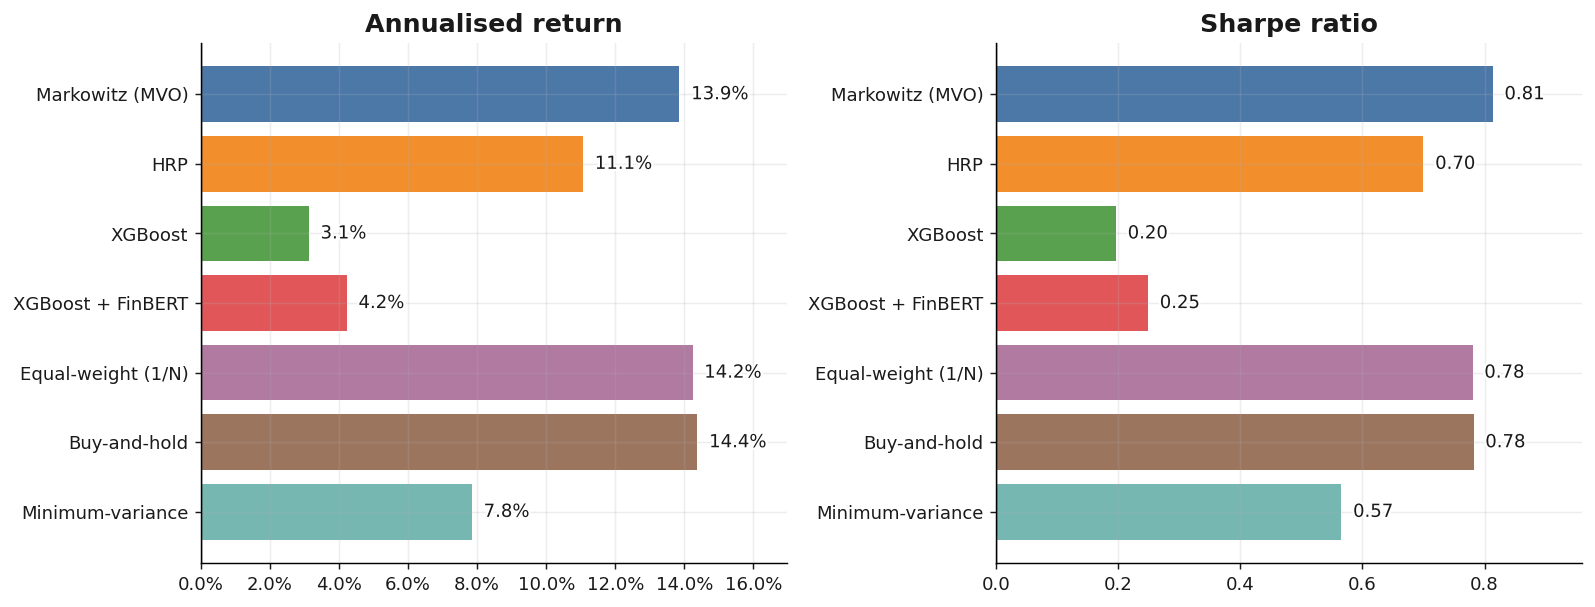

In [6]:
chart_metrics = [c for c in ["annualized_return", "sharpe_ratio"] if c in metrics_raw.columns]
if chart_metrics:
    fig, axes = plt.subplots(1, len(chart_metrics), figsize=(6.2 * len(chart_metrics), 4.8))
    axes = np.atleast_1d(axes)
    for ax, metric in zip(axes, chart_metrics):
        values = metrics_raw[metric].dropna()
        keys = existing_order(values.index)
        values = values.loc[keys]
        bars = ax.barh([label(k) for k in keys], values, color=[color(k) for k in keys])
        ax.axvline(0, color="#333333", linewidth=0.8)
        ax.set_title("Annualised return" if metric == "annualized_return" else "Sharpe ratio")
        if metric == "annualized_return":
            ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
            value_fmt = lambda x: f"{x:.1%}"
        else:
            value_fmt = lambda x: f"{x:.2f}"
        annotate_hbars(ax, bars, values, value_fmt, fontsize=10)
        ax.invert_yaxis()
    finish_figure(fig, filename="01_headline_bars")


<a id="sec2"></a>
## 2. Cumulative wealth and data coverage

All strategies are plotted on their common set of valid return dates. Missing
returns are not silently converted to zero, because that could bias wealth and
drawdown comparisons when a strategy has a genuine data gap.

,First valid date,Last valid date,Missing observations,Available observations
Markowitz (MVO),2019-02-01,2025-12-31,0,1788
HRP,2019-02-01,2025-12-31,0,1788
XGBoost,2019-02-01,2025-12-31,0,1788
XGBoost + FinBERT,2019-02-01,2025-12-31,0,1788
Equal-weight (1/N),2019-02-01,2025-12-31,0,1788
Buy-and-hold,2019-02-01,2025-12-31,0,1788
Minimum-variance,2019-02-01,2025-12-31,0,1788


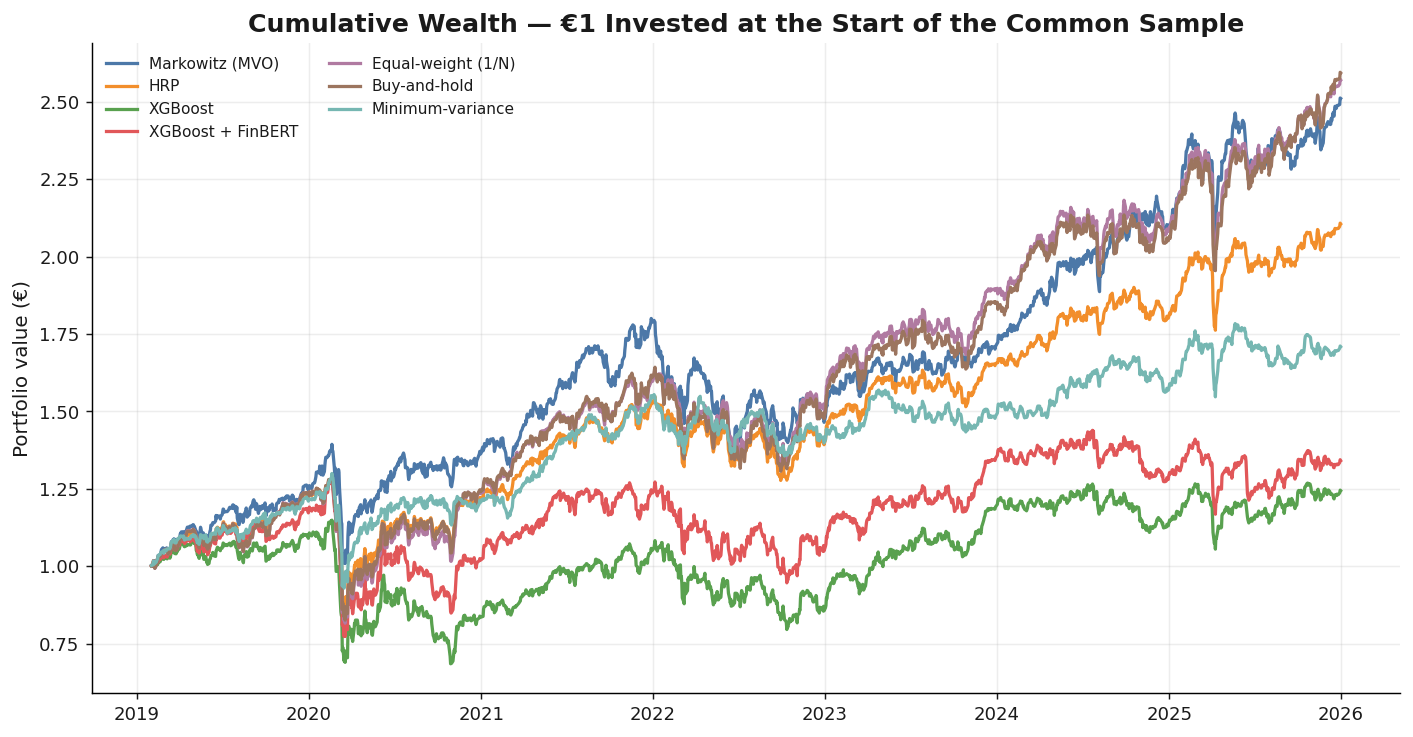

In [7]:
returns_raw = pd.read_csv(PORTFOLIO_RETURNS_FILE, index_col=0, parse_dates=True).sort_index()
returns_raw = returns_raw.loc[:, existing_order(returns_raw.columns)]

coverage = pd.DataFrame({
    "First valid date": returns_raw.apply(lambda s: s.first_valid_index()),
    "Last valid date": returns_raw.apply(lambda s: s.last_valid_index()),
    "Missing observations": returns_raw.isna().sum(),
    "Available observations": returns_raw.notna().sum(),
}).rename(index=STRATEGY_LABELS)
display(coverage.style.format({
    "First valid date": lambda value: value.strftime("%Y-%m-%d") if pd.notna(value) else "—",
    "Last valid date": lambda value: value.strftime("%Y-%m-%d") if pd.notna(value) else "—",
}).set_caption("Return-series coverage"))

returns = returns_raw.dropna(how="any")
if returns.empty:
    raise ValueError("No common complete return period exists across strategies.")
if len(returns) < len(returns_raw):
    warnings.warn(
        f"Dropped {len(returns_raw) - len(returns)} date(s) with at least one missing strategy return."
    )
if (returns <= -1).any().any():
    raise ValueError("Portfolio returns contain a value at or below -100%.")

wealth = (1.0 + returns).cumprod()
fig, ax = plt.subplots(figsize=(11, 5.8))
for strategy in wealth.columns:
    ax.plot(wealth.index, wealth[strategy], label=label(strategy),
            color=color(strategy), linewidth=1.8)
ax.set_title("Cumulative Wealth — €1 Invested at the Start of the Common Sample")
ax.set_ylabel("Portfolio value (€)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper left", ncol=2, fontsize=8.5)
finish_figure(fig, filename="02_cumulative_wealth")

<a id="sec3"></a>
## 3. Drawdown paths

Drawdowns show when risk materialised and support the regime-specific comparison
between HRP and Markowitz.

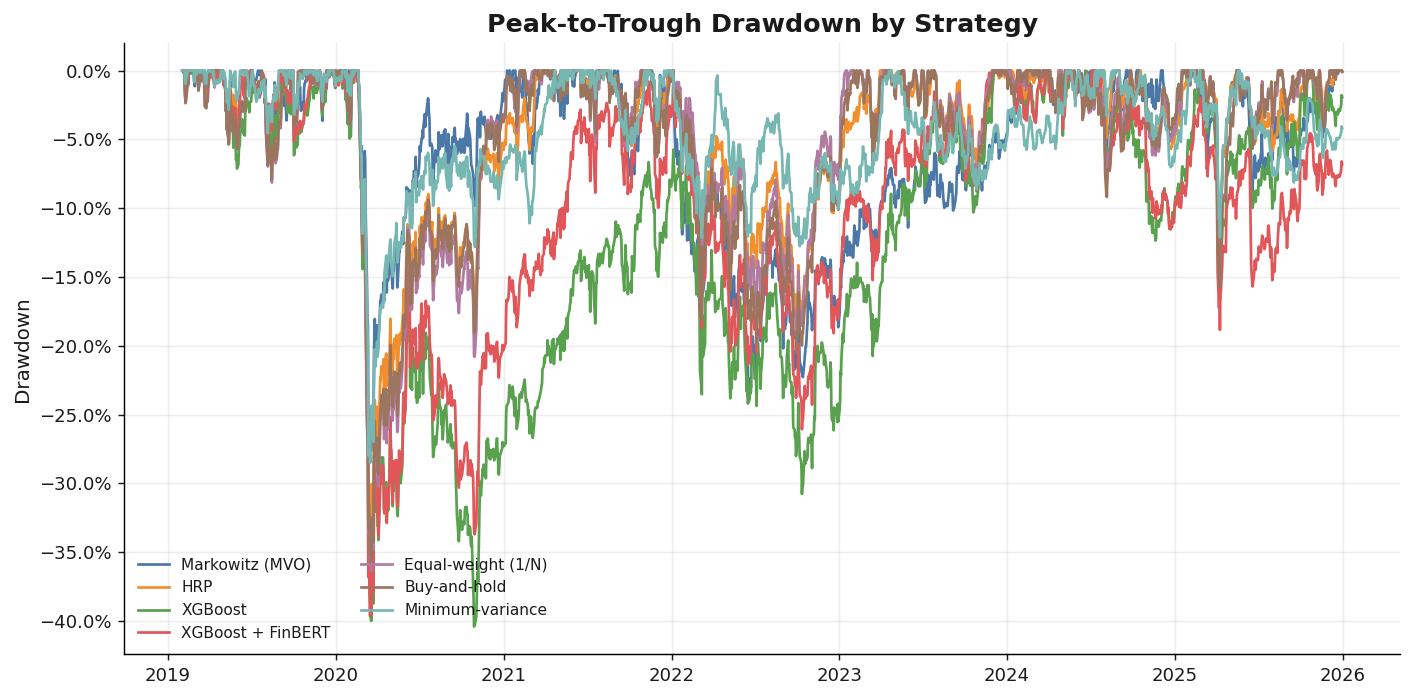

In [8]:
drawdowns = wealth.div(wealth.cummax()).sub(1.0)
fig, ax = plt.subplots(figsize=(11, 5.5))
for strategy in drawdowns.columns:
    ax.plot(drawdowns.index, drawdowns[strategy], label=label(strategy),
            color=color(strategy), linewidth=1.5)
ax.set_title("Peak-to-Trough Drawdown by Strategy")
ax.set_ylabel("Drawdown")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="lower left", ncol=2, fontsize=8.5)
finish_figure(fig, filename="03_drawdowns")

<a id="sec4"></a>
## 4. Turnover and transaction-cost sensitivity

The first panel reports mean turnover per rebalancing from the transaction log.
The second reports annualised turnover from the evaluation metrics. Keeping the
two definitions separate avoids calling a per-rebalance mean “annualised.”

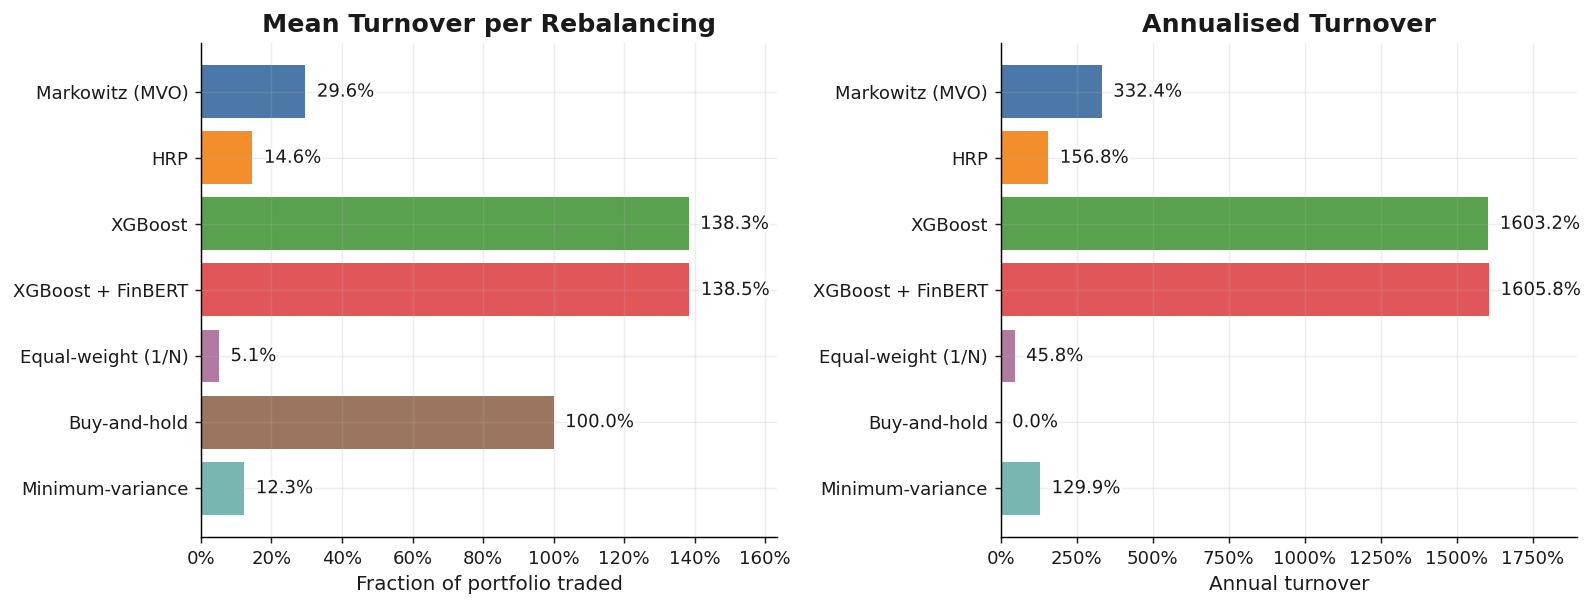

In [9]:
turnover_log = pd.read_csv(TURNOVER_FILE, index_col=0, parse_dates=True)
require_columns(turnover_log, ["strategy", "turnover"], "turnover history")
mean_turnover = turnover_log.groupby("strategy")["turnover"].mean().dropna()
mean_turnover = mean_turnover.loc[existing_order(mean_turnover.index)]

has_annual_turnover = "annualized_turnover" in metrics_raw.columns
ncols = 2 if has_annual_turnover else 1
fig, axes = plt.subplots(1, ncols, figsize=(6.2 * ncols, 4.8))
axes = np.atleast_1d(axes)

keys = list(mean_turnover.index)
bars0 = axes[0].barh([label(k) for k in keys], mean_turnover.values,
                     color=[color(k) for k in keys])
axes[0].set_title("Mean Turnover per Rebalancing")
axes[0].set_xlabel("Fraction of portfolio traded")
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
annotate_hbars(axes[0], bars0, mean_turnover.values, lambda x: f"{x:.1%}", fontsize=10)
axes[0].invert_yaxis()

if has_annual_turnover:
    annual_turnover = metrics_raw["annualized_turnover"].dropna()
    annual_turnover = annual_turnover.loc[existing_order(annual_turnover.index)]
    keys = list(annual_turnover.index)
    bars1 = axes[1].barh([label(k) for k in keys], annual_turnover.values,
                         color=[color(k) for k in keys])
    axes[1].set_title("Annualised Turnover")
    axes[1].set_xlabel("Annual turnover")
    axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    annotate_hbars(axes[1], bars1, annual_turnover.values, lambda x: f"{x:.1%}", fontsize=10)
    axes[1].invert_yaxis()

finish_figure(fig, filename="04a_turnover")


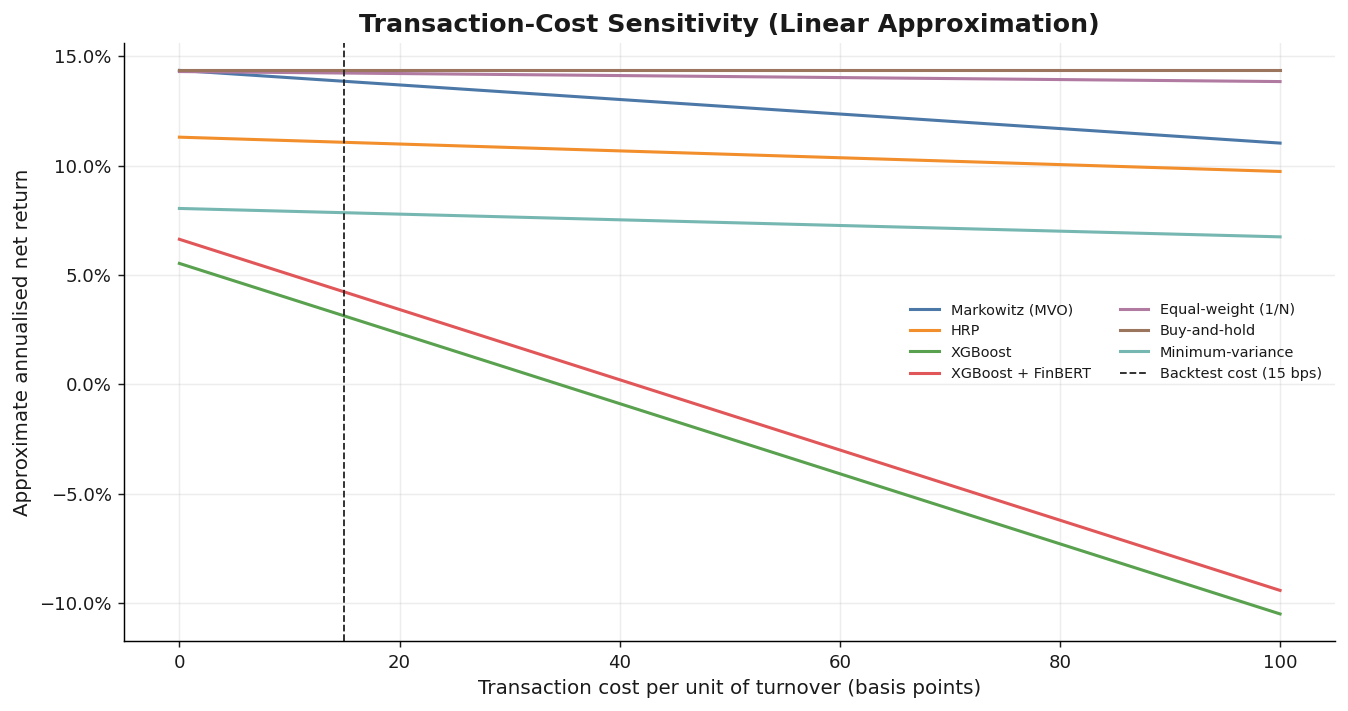

,Breakeven vs 1/N (bps),Interpretation
Strategy,,
Markowitz (MVO),1.8,Positive crossing
HRP,—,No positive crossing under linear approximation
XGBoost,—,No positive crossing under linear approximation
XGBoost + FinBERT,—,No positive crossing under linear approximation
Buy-and-hold,—,No positive crossing under linear approximation
Minimum-variance,—,No positive crossing under linear approximation


In [10]:
# Linear sensitivity approximation:
# gross proxy = reported net annual return + baseline cost × annual turnover.
# This is a transparent diagnostic, not a rerun of the daily backtest.
breakeven = None
if {"annualized_return", "annualized_turnover"}.issubset(metrics_raw.columns):
    sensitivity_input = metrics_raw[["annualized_return", "annualized_turnover"]].dropna()
    baseline_rate = BASELINE_COST_BPS / 10_000
    gross_proxy = (sensitivity_input["annualized_return"]
                   + baseline_rate * sensitivity_input["annualized_turnover"])
    cost_grid_bps = np.arange(0, 101, 5)
    sensitivity = pd.DataFrame(index=cost_grid_bps)
    for strategy, row in sensitivity_input.iterrows():
        sensitivity[strategy] = (
            gross_proxy[strategy]
            - (cost_grid_bps / 10_000) * row["annualized_turnover"]
        )

    fig, ax = plt.subplots(figsize=(10.5, 5.6))
    for strategy in sensitivity.columns:
        ax.plot(sensitivity.index, sensitivity[strategy], label=label(strategy),
                color=color(strategy), linewidth=1.7)
    ax.axvline(BASELINE_COST_BPS, color="#222222", linestyle="--", linewidth=1,
               label=f"Backtest cost ({BASELINE_COST_BPS} bps)")
    ax.set_title("Transaction-Cost Sensitivity (Linear Approximation)")
    ax.set_xlabel("Transaction cost per unit of turnover (basis points)")
    ax.set_ylabel("Approximate annualised net return")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.legend(loc="best", ncol=2, fontsize=8)
    finish_figure(fig, filename="04b_cost_sensitivity")

    benchmark = "equal_weight"
    breakeven_rows = []
    if benchmark in sensitivity_input.index:
        for strategy in sensitivity_input.index:
            if strategy == benchmark:
                continue
            delta_turnover = (sensitivity_input.loc[strategy, "annualized_turnover"]
                              - sensitivity_input.loc[benchmark, "annualized_turnover"])
            delta_gross = gross_proxy[strategy] - gross_proxy[benchmark]
            raw_breakeven_bps = (delta_gross / delta_turnover * 10_000
                                 if delta_turnover > 0 else np.nan)
            breakeven_bps = (raw_breakeven_bps
                             if pd.notna(raw_breakeven_bps) and raw_breakeven_bps >= 0
                             else np.nan)
            interpretation = (
                "Positive crossing" if pd.notna(breakeven_bps) and breakeven_bps >= 0
                else "No positive crossing under linear approximation"
            )
            breakeven_rows.append({
                "Strategy": label(strategy),
                "Breakeven vs 1/N (bps)": breakeven_bps,
                "Interpretation": interpretation,
            })
        breakeven = pd.DataFrame(breakeven_rows).set_index("Strategy")
        styled_breakeven = breakeven.style.format(
            {"Breakeven vs 1/N (bps)": "{:.1f}"}, na_rep="—")
        styled_breakeven = styled_breakeven.map(
            lambda value: (HIGHLIGHT_PROPS if isinstance(value, str) and value.startswith("Positive")
                          else f"background-color:{NEUTRAL_COLOR};color:#1a1a1a;font-weight:600"),
            subset=["Interpretation"],
        )
        display(styled_breakeven.set_caption(
            "Approximate transaction-cost breakeven versus equal weighting — dark green: "
            "a positive breakeven cost was found under the linear approximation"))
else:
    print("Annualised return/turnover columns are unavailable; cost sensitivity skipped.")


<a id="sec4b"></a>
### 4c. Turnover-damping robustness check

The cost-sensitivity chart above is a linear approximation on top of the
reported metrics, not a rerun of the daily simulation. This section is
that rerun: the already-fitted forecasts and target weights from the main
backtest are re-simulated at slower trade-toward-target speeds
(damping < 1.0), so the comparison isolates the effect of trading less
aggressively from any change in the forecasts themselves. Produced by
`test_turnover_damping.py`.


,Sharpe (damping=1),Sharpe (damping=0.5),Sharpe (damping=0.3),Sharpe (damping=0.15),Δ Sharpe (damping=0.15 vs 1)
Markowitz (MVO),0.813,0.824,0.837,0.859,0.046
HRP,0.700,0.718,0.726,0.738,0.038
XGBoost,0.196,0.421,0.524,0.641,0.445
XGBoost + FinBERT,0.249,0.479,0.578,0.683,0.434
Equal-weight (1/N),0.780,0.783,0.787,0.794,0.014


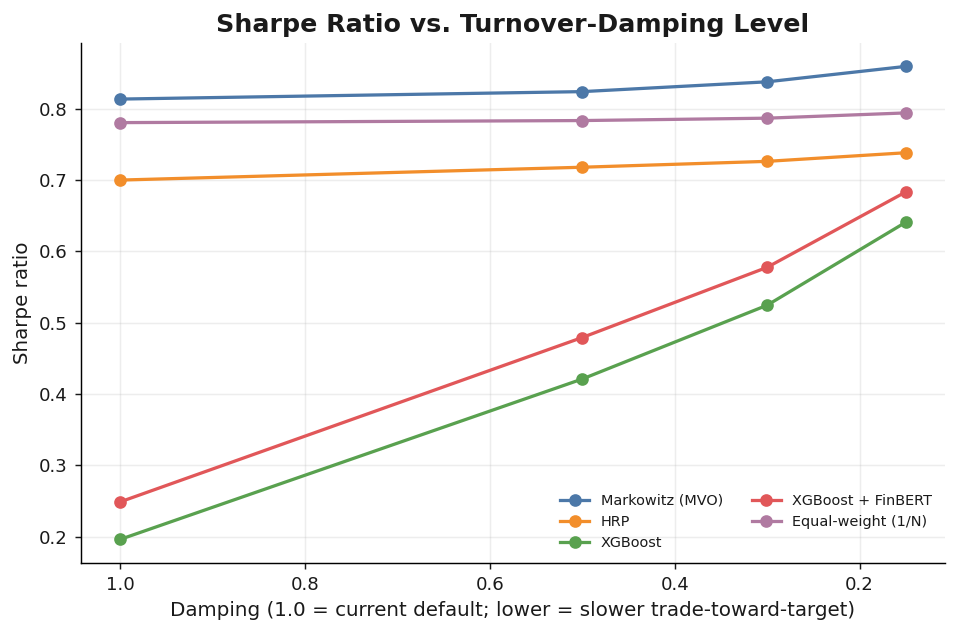

In [11]:
damping_raw = optional_csv(RESULTS_DIR / "turnover_damping_sensitivity.csv")

if damping_raw is not None:
    require_columns(damping_raw, ["damping", "strategy", "sharpe"],
                    "turnover damping sensitivity")

    pivot = damping_raw.pivot(index="strategy", columns="damping", values="sharpe")
    pivot = pivot.loc[existing_order(pivot.index)]
    damping_levels = sorted(pivot.columns, reverse=True)
    pivot = pivot[damping_levels]
    baseline, most_damped = damping_levels[0], damping_levels[-1]
    delta = pivot[most_damped] - pivot[baseline]

    display_table = pivot.copy()
    display_table.columns = [f"Sharpe (damping={d:g})" for d in damping_levels]
    delta_col = f"Δ Sharpe (damping={most_damped:g} vs {baseline:g})"
    display_table[delta_col] = delta.values
    display_table.index = [label(s) for s in pivot.index]

    styled = display_table.style.format("{:.3f}")
    styled = sign_style(styled, subset=[delta_col], neutral_band=0.02)
    display(styled.set_caption(
        "Turnover-damping robustness check — same fitted forecasts, no "
        "retraining. Final column: dark green = damping meaningfully "
        "improved the Sharpe ratio, amber = little change."
    ))

    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    for strategy in pivot.index:
        ax.plot(damping_levels, pivot.loc[strategy].values, marker="o",
                label=label(strategy), color=color(strategy), linewidth=1.8)
    ax.set_title("Sharpe Ratio vs. Turnover-Damping Level")
    ax.set_xlabel("Damping (1.0 = current default; lower = slower trade-toward-target)")
    ax.set_ylabel("Sharpe ratio")
    ax.invert_xaxis()
    ax.legend(loc="best", fontsize=8, ncol=2)
    finish_figure(fig, filename="04c_turnover_damping")
else:
    print("turnover_damping_sensitivity.csv not found -- run "
         "test_turnover_damping.py first to include this robustness check.")


<a id="sec5"></a>
## 5. Feature importance: XGBoost ablation diagnostic

This plot shows how the two fitted XGBoost models allocate gain across features.
Feature importance is descriptive and model-specific; it is not causal evidence.
The portfolio comparison and bootstrap test remain the primary evidence for the
sentiment research question.

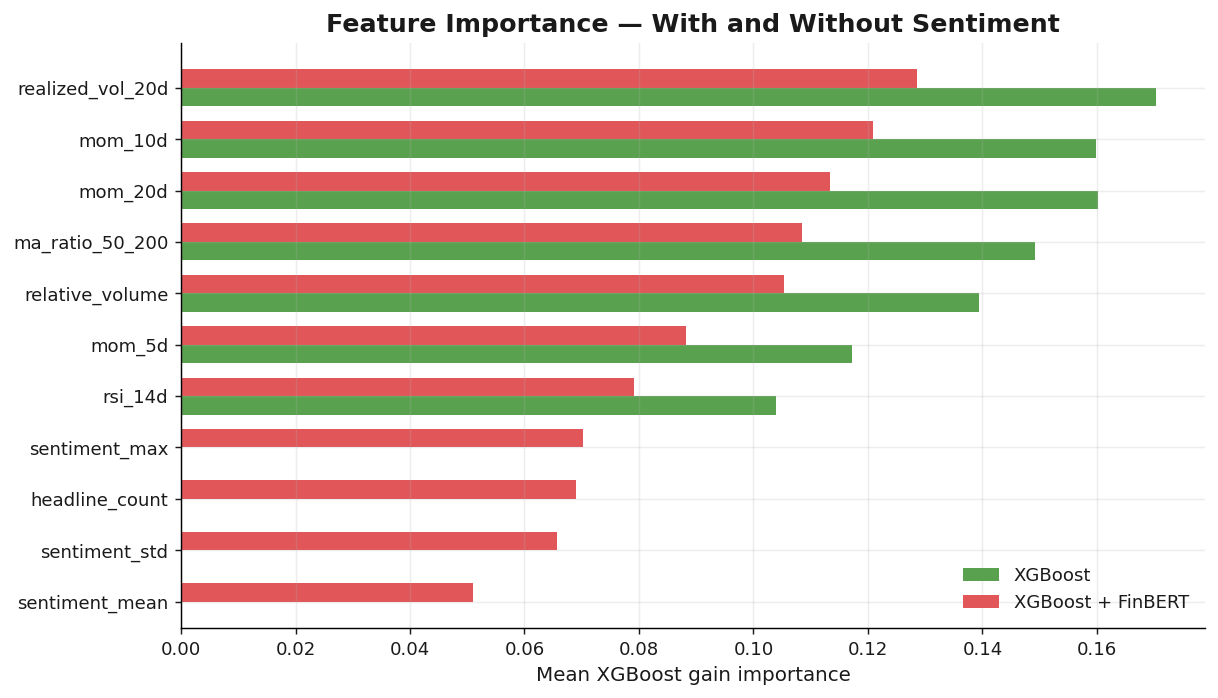

In [12]:
importance = optional_csv(FEATURE_IMPORTANCE_FILE)
if importance is None:
    print(f"{FEATURE_IMPORTANCE_FILE} not found or empty — run Evaluate.py first.")
else:
    require_columns(importance, ["method"], "feature importance")
    numeric = importance.drop(columns=["date"], errors="ignore").select_dtypes(include="number")
    importance_numeric = pd.concat([importance[["method"]], numeric], axis=1)
    avg_importance = importance_numeric.groupby("method").mean().T
    required_models = ["xgb", "xgb_sentiment"]
    if set(required_models).issubset(avg_importance.columns):
        plot_df = avg_importance[required_models].copy()
        plot_df = plot_df.loc[plot_df.max(axis=1).nlargest(min(15, len(plot_df))).index]
        plot_df = plot_df.sort_values("xgb_sentiment")
        y = np.arange(len(plot_df))
        fig, ax = plt.subplots(figsize=(9.5, max(5.5, 0.38 * len(plot_df))))
        ax.barh(y - 0.18, plot_df["xgb"], height=0.36,
                label="XGBoost", color=color("xgb"))
        ax.barh(y + 0.18, plot_df["xgb_sentiment"], height=0.36,
                label="XGBoost + FinBERT", color=color("xgb_sentiment"))
        ax.set_yticks(y)
        ax.set_yticklabels(plot_df.index)
        ax.set_xlabel("Mean XGBoost gain importance")
        ax.set_title("Feature Importance — With and Without Sentiment")
        ax.legend(loc="lower right")
        finish_figure(fig, filename="05_feature_importance")
    else:
        print("Both xgb and xgb_sentiment methods are required for the ablation plot.")

<a id="sec6"></a>
## 6. Statistical significance: stationary-bootstrap Sharpe tests

The 5% significance decision is shown explicitly instead of using an ambiguous
continuous green gradient. Pay particular attention to XGBoost versus
XGBoost + FinBERT, the thesis's primary ablation comparison.

In [22]:
boot = optional_csv(BOOTSTRAP_FILE)
if boot is None:
    print(f"{BOOTSTRAP_FILE} not found or empty — run Evaluate.py first.")
    boot_display = None
    sig_col = None
else:
    boot_display = boot.copy()
    strategy_cols = [c for c in boot_display.columns
                     if c.lower() in {"strategy_a", "strategy_b"}]
    for column in strategy_cols:
        boot_display[column] = boot_display[column].map(label)
    sig_col = next((c for c in boot_display.columns
                    if "p_value" in c.lower() or "pvalue" in c.lower()), None)
    if sig_col is not None:
        boot_display[sig_col] = pd.to_numeric(boot_display[sig_col], errors="coerce")
        boot_display["Significant at 5%"] = boot_display[sig_col] < ALPHA
        boot_display = boot_display.sort_values(sig_col, na_position="last")

    formats = {column: "{:.4f}" for column in boot_display.select_dtypes(include="number").columns}
    styled_boot = boot_display.style.format(formats, na_rep="—")

    # Colour any Sharpe-ratio "difference"/"delta" column dark green/red/amber
    # by sign so a positive versus negative gap is legible at a glance.
    diff_columns = [c for c in boot_display.select_dtypes(include="number").columns
                    if "diff" in c.lower() or "delta" in c.lower()]
    if diff_columns:
        styled_boot = sign_style(styled_boot, subset=diff_columns)

    if "Significant at 5%" in boot_display.columns:
        styled_boot = styled_boot.map(
            lambda value: (HIGHLIGHT_PROPS if value is True
                          else f"background-color:{NEUTRAL_COLOR};color:#1a1a1a;font-weight:600"),
            subset=["Significant at 5%"],
        )
    display(styled_boot.set_caption(
        "Stationary bootstrap: Sharpe-ratio differences (5,000 iterations; α = 0.05) "
        "— dark green: significant at 5%, amber: not significant"))


,strategy_a,strategy_b,sharpe_a,sharpe_b,difference,ci_lower_95,ci_upper_95,p_value,significant_at_5pct,observations,Significant at 5%
6,XGBoost,Equal-weight (1/N),0.1962,0.7803,-0.5841,-0.9417,-0.2874,0.0014,True,1788.0000,True
3,XGBoost + FinBERT,Equal-weight (1/N),0.2488,0.7803,-0.5315,-0.8836,-0.2402,0.0018,True,1788.0000,True
5,XGBoost,HRP,0.1962,0.6998,-0.5036,-0.8725,-0.2018,0.0044,True,1788.0000,True
2,XGBoost + FinBERT,HRP,0.2488,0.6998,-0.4510,-0.8078,-0.1661,0.0066,True,1788.0000,True
4,XGBoost,Markowitz (MVO),0.1962,0.8133,-0.6171,-1.1083,-0.1217,0.0146,True,1788.0000,True
1,XGBoost + FinBERT,Markowitz (MVO),0.2488,0.8133,-0.5645,-1.0328,-0.0938,0.0202,True,1788.0000,True
8,HRP,Equal-weight (1/N),0.6998,0.7803,-0.0805,-0.2628,0.1051,0.3842,False,1788.0000,False
7,HRP,Markowitz (MVO),0.6998,0.8133,-0.1135,-0.4546,0.2966,0.5630,False,1788.0000,False
0,XGBoost + FinBERT,XGBoost,0.2488,0.1962,0.0526,-0.1294,0.2326,0.5680,False,1788.0000,False
9,Markowitz (MVO),Equal-weight (1/N),0.8133,0.7803,0.0330,-0.4611,0.4624,0.8872,False,1788.0000,False


<a id="sec7"></a>
## 7. Performance by market regime

The Sharpe-ratio heatmap directly supports the question of whether HRP performs
better than Markowitz during volatile periods. The colour scale is centred at
zero so positive and negative risk-adjusted performance are visually distinct.

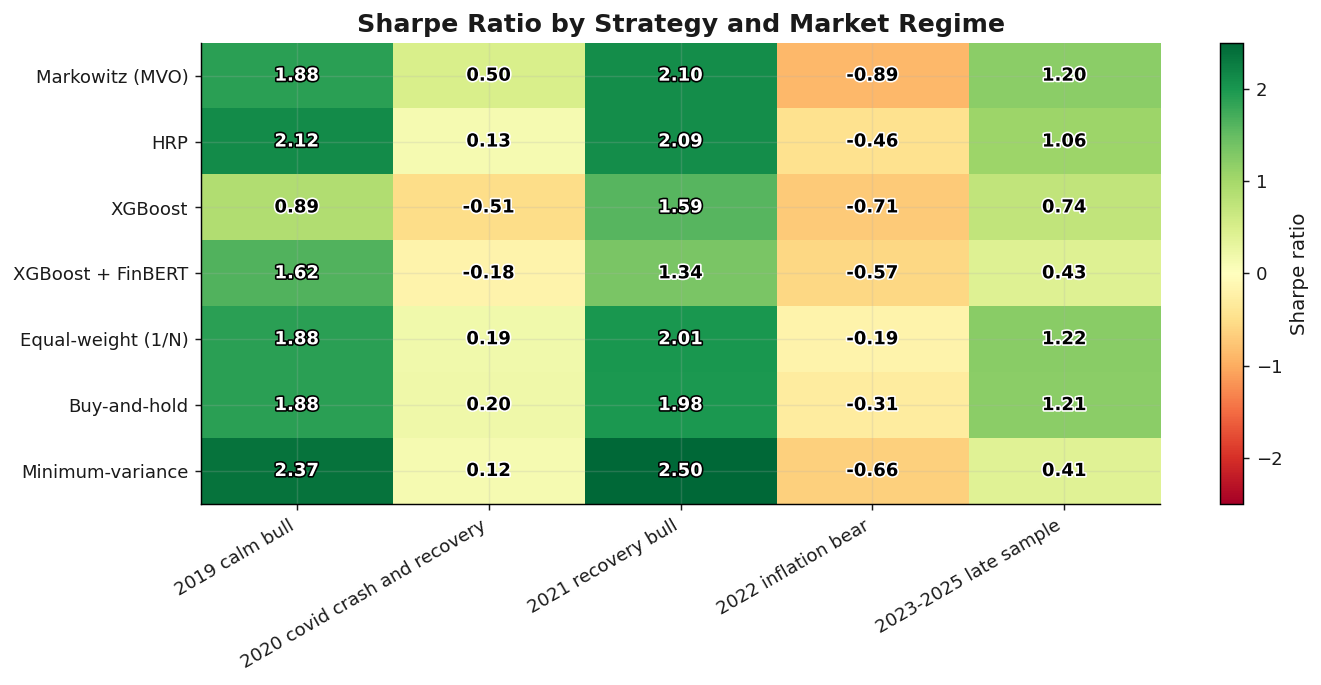

In [23]:
subperiod = optional_csv(SUBPERIOD_METRICS_FILE)
regime_pivot = None
if subperiod is None:
    print(f"{SUBPERIOD_METRICS_FILE} not found or empty — run Evaluate.py first.")
else:
    strategy_col = next((c for c in subperiod.columns if c.lower() == "strategy"), None)
    sharpe_col = next((c for c in subperiod.columns if "sharpe" in c.lower()), None)
    period_col = next((c for c in subperiod.columns
                       if "period" in c.lower() or "regime" in c.lower()), None)
    if not all([strategy_col, sharpe_col, period_col]):
        print("Could not identify strategy, regime, and Sharpe columns. Raw table:")
        display(subperiod)
    else:
        regime_pivot = subperiod.pivot_table(
            index=strategy_col, columns=period_col, values=sharpe_col, aggfunc="mean"
        )
        regime_pivot = regime_pivot.loc[existing_order(regime_pivot.index)]
        labelled_index = [label(s) for s in regime_pivot.index]
        values = regime_pivot.to_numpy(dtype=float)
        finite = values[np.isfinite(values)]
        limit = max(abs(finite.min()), abs(finite.max()), 1e-9) if finite.size else 1.0
        norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)

        fig, ax = plt.subplots(figsize=(11, 5.4))
        image = ax.imshow(values, cmap="RdYlGn", norm=norm, aspect="auto")
        ax.set_xticks(range(len(regime_pivot.columns)))
        ax.set_xticklabels(regime_pivot.columns, rotation=30, ha="right")
        ax.set_yticks(range(len(regime_pivot.index)))
        ax.set_yticklabels(labelled_index)
        for i in range(values.shape[0]):
            for j in range(values.shape[1]):
                value = values[i, j]
                if np.isfinite(value):
                    text_color = "white" if abs(value) > 0.6 * limit else "black"
                    halo_color = "black" if text_color == "white" else "white"
                    cell_text = ax.text(j, i, f"{value:.2f}", ha="center", va="center",
                                        fontsize=10, fontweight="bold", color=text_color)
                    cell_text.set_path_effects([
                        path_effects.withStroke(linewidth=1.8, foreground=halo_color)
                    ])
        ax.set_title("Sharpe Ratio by Strategy and Market Regime")
        fig.colorbar(image, ax=ax, label="Sharpe ratio")
        finish_figure(fig, filename="07_regime_heatmap")


<a id="sec8"></a>
## 8. Prediction accuracy: XGBoost versus XGBoost + FinBERT

This is a model-level diagnostic independent of portfolio construction. The
portfolio results should remain the primary basis for answering the thesis's
main question.

,MAE,Median absolute error
XGBoost,5.482%,4.139%
XGBoost + FinBERT,5.481%,4.163%


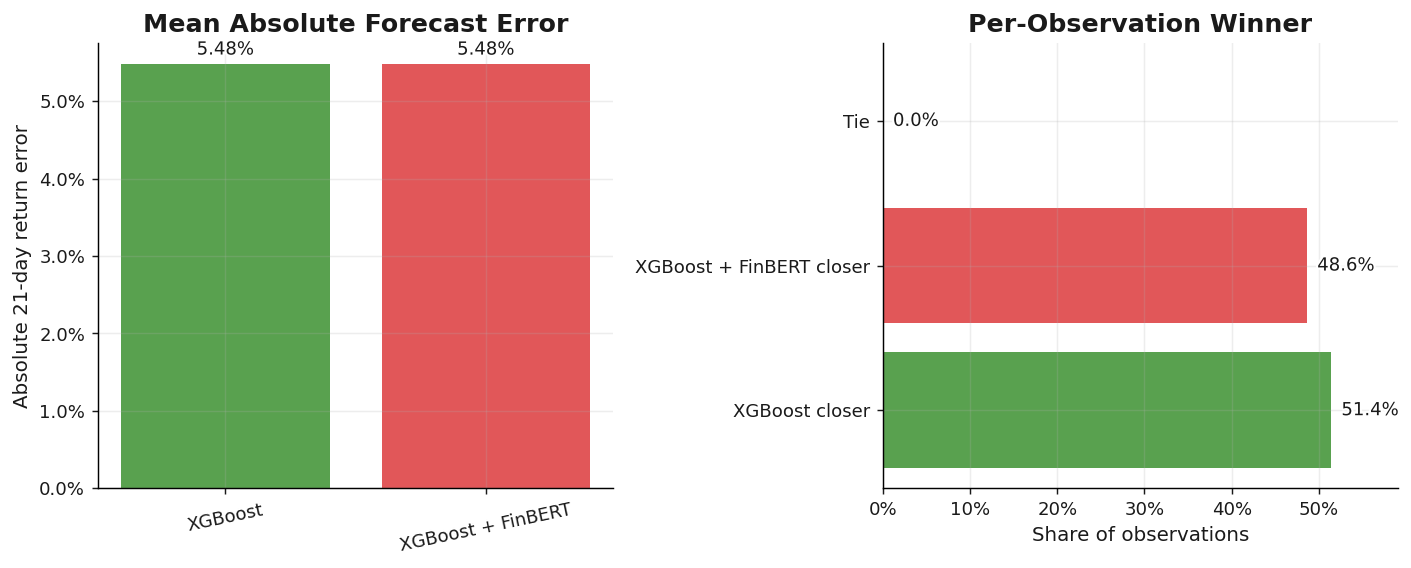

In [24]:
prediction_candidates = [
    RESULTS_DIR / "complete_asset_full_comparison.csv",
    RESULTS_DIR / "prediction_accuracy.csv",
]
pred_acc_path = next((path for path in prediction_candidates if path.exists()), None)
pred_acc = optional_csv(pred_acc_path) if pred_acc_path is not None else None

if pred_acc is not None:
    pred_acc = pred_acc.rename(columns={
        "Date": "date",
        "Ticker": "ticker",
        "Actual": "actual",
        "XGBoost": "xgb_predicted",
        "XGBoost+Sentiment": "xgb_sentiment_predicted",
    })
    # Appendix B recomputes the Markowitz path consistently from clean prices.
    pred_acc = pred_acc.drop(columns=["Markowitz (implied)"], errors="ignore")
    if "date" in pred_acc.columns:
        pred_acc["date"] = pd.to_datetime(pred_acc["date"], errors="coerce")
    required_predictions = {
        "ticker", "actual", "xgb_predicted", "xgb_sentiment_predicted"
    }
    if required_predictions.issubset(pred_acc.columns):
        pred_acc["xgb_abs_error"] = (
            pred_acc["xgb_predicted"] - pred_acc["actual"]
        ).abs()
        pred_acc["xgb_sentiment_abs_error"] = (
            pred_acc["xgb_sentiment_predicted"] - pred_acc["actual"]
        ).abs()
        difference = (
            pred_acc["xgb_abs_error"] - pred_acc["xgb_sentiment_abs_error"]
        )
        pred_acc["closer_model"] = np.select(
            [difference > 1e-12, difference < -1e-12],
            ["xgb_sentiment", "xgb"],
            default="tie",
        )

if pred_acc is None:
    expected = ", ".join(path.name for path in prediction_candidates)
    print(f"No prediction-accuracy file found ({expected}); optional section skipped.")
else:
    require_columns(pred_acc, [
        "ticker", "actual", "xgb_abs_error", "xgb_sentiment_abs_error",
        "closer_model"
    ], "prediction accuracy")
    model_summary = pd.DataFrame({
        "MAE": [pred_acc["xgb_abs_error"].mean(),
                pred_acc["xgb_sentiment_abs_error"].mean()],
        "Median absolute error": [pred_acc["xgb_abs_error"].median(),
                                  pred_acc["xgb_sentiment_abs_error"].median()],
    }, index=["XGBoost", "XGBoost + FinBERT"])
    display(model_summary.style.format("{:.3%}")
            .highlight_min(axis=0, props=HIGHLIGHT_PROPS)
            .set_caption(
                f"Forecast accuracy across {len(pred_acc):,} ticker-date observations "
                f"from {pred_acc_path.name} — dark green marks the lower-error model"
            ))

    win_counts = pred_acc["closer_model"].value_counts()
    categories = ["xgb", "xgb_sentiment", "tie"]
    proportions = pd.Series(
        [win_counts.get(category, 0) / len(pred_acc) for category in categories],
        index=["XGBoost closer", "XGBoost + FinBERT closer", "Tie"],
    )
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    bars0 = axes[0].bar(model_summary.index, model_summary["MAE"],
                color=[color("xgb"), color("xgb_sentiment")])
    axes[0].set_title("Mean Absolute Forecast Error")
    axes[0].set_ylabel("Absolute 21-day return error")
    axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[0].tick_params(axis="x", rotation=12)
    annotate_bars(axes[0], [bars0], value_fmt=lambda v: f"{v:.2%}", fontsize=10)

    bars1 = axes[1].barh(proportions.index, proportions.values,
                 color=[color("xgb"), color("xgb_sentiment"), "#B0B0B0"])
    axes[1].set_title("Per-Observation Winner")
    axes[1].set_xlabel("Share of observations")
    axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[1].set_xlim(0, max(0.55, proportions.max() * 1.15))
    annotate_hbars(axes[1], bars1, proportions.values,
                   lambda x: f"{x:.1%}", fontsize=10)
    finish_figure(fig, filename="08_prediction_accuracy")


<a id="sec9"></a>
## 9. Per-asset sentiment effect

The chart identifies the five assets for which sentiment reduced forecast MAE
the most and the five for which it increased MAE the most. Selection is based
on the full out-of-sample period, not on a single forecast.

,n_predictions,xgb_mae,xgb_sentiment_mae,sentiment_win_rate_ex_ties,mae_improvement
ticker,,,,,
ITX.MC,83,6.154%,5.981%,53.0%,+0.172%
INGA.AS,83,8.122%,8.039%,51.8%,+0.083%
BNP.PA,83,7.859%,7.792%,67.5%,+0.067%
ALV.DE,83,5.061%,4.994%,59.0%,+0.067%
SIE.DE,83,6.306%,6.243%,50.6%,+0.063%
ENEL.MI,83,4.855%,4.901%,45.8%,-0.046%
EXV1.DE,83,5.710%,5.759%,33.7%,-0.049%
EXV6.DE,83,5.628%,5.698%,43.4%,-0.069%
AIR.PA,83,6.985%,7.056%,44.6%,-0.071%


Displayed 5 asset(s) for which sentiment reduced MAE and 5 asset(s) for which sentiment increased MAE.


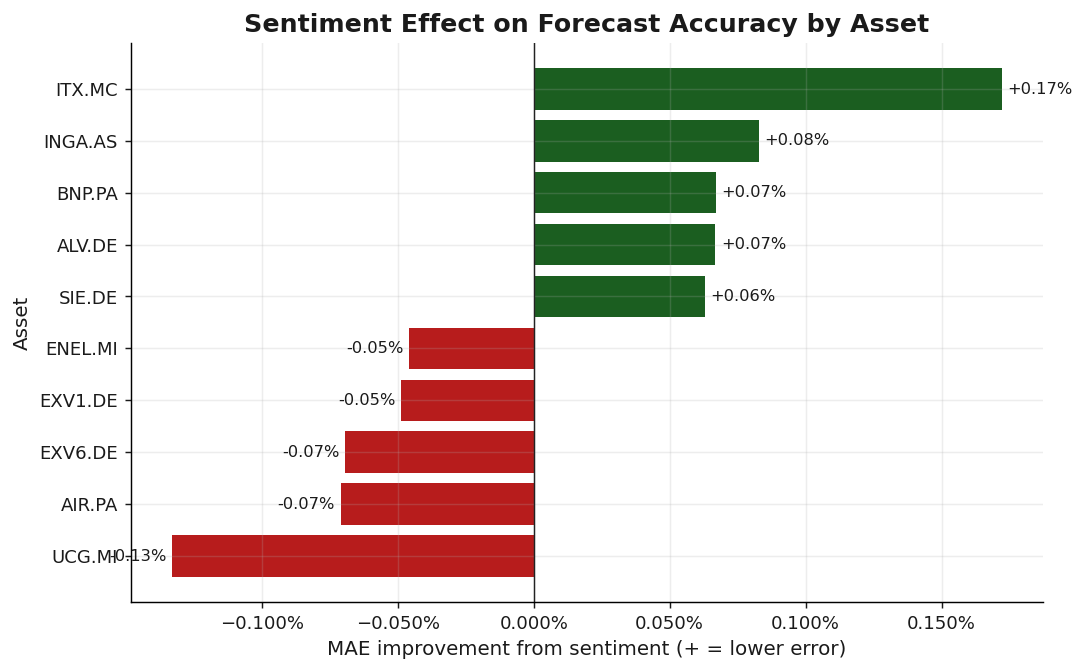

In [25]:
per_ticker = None

if pred_acc is None:
    print(
        "Prediction-accuracy data unavailable; "
        "per-asset section skipped."
    )

else:
    # ---------------------------------------------------------------
    # Calculate forecast accuracy for every asset
    # ---------------------------------------------------------------

    per_ticker = pred_acc.groupby("ticker").agg(
        n_predictions=("actual", "count"),
        xgb_mae=("xgb_abs_error", "mean"),
        xgb_sentiment_mae=(
            "xgb_sentiment_abs_error",
            "mean",
        ),
    )

    # Exclude tied forecasts when calculating the sentiment win rate.
    non_ties = pred_acc[
        pred_acc["closer_model"] != "tie"
    ]

    win_rate = (
        non_ties.groupby("ticker")["closer_model"]
        .apply(
            lambda values:
            (values == "xgb_sentiment").mean()
        )
    )

    per_ticker["sentiment_win_rate_ex_ties"] = (
        win_rate.reindex(per_ticker.index)
    )

    # Positive improvement:
    # FinBERT sentiment produced a lower MAE.
    #
    # Negative improvement:
    # FinBERT sentiment produced a higher MAE.
    per_ticker["mae_improvement"] = (
        per_ticker["xgb_mae"]
        - per_ticker["xgb_sentiment_mae"]
    )

    # ---------------------------------------------------------------
    # Select the five most-helped and five most-hurt assets
    # ---------------------------------------------------------------
    #
    # Selection is based on the full out-of-sample period (mean
    # absolute error across all 84 rebalancing dates per ticker),
    # not on any single forecast.

    MAX_ASSETS_PER_SIDE = 5

    helped = (
        per_ticker[per_ticker["mae_improvement"] > 0]
        .nlargest(MAX_ASSETS_PER_SIDE, "mae_improvement")
    )

    hurt = (
        per_ticker[per_ticker["mae_improvement"] < 0]
        .nsmallest(MAX_ASSETS_PER_SIDE, "mae_improvement")
    )

    curated = pd.concat([helped, hurt], axis=0)
    curated = (
        curated
        .loc[lambda frame: ~frame.index.duplicated()]
        .sort_values("mae_improvement")
    )

    # ---------------------------------------------------------------
    # Display results
    # ---------------------------------------------------------------

    if curated.empty:
        print(
            "No positive or negative sentiment-related "
            "MAE differences were identified."
        )

    else:
        selection_caption = (
            f"Sentiment effect by asset: "
            f"{len(helped)} helped and {len(hurt)} hurt"
        )

        formatted_table = (
            curated
            .sort_values(
                "mae_improvement",
                ascending=False,
            )
            .style
            .format(
                {
                    "n_predictions": "{:,.0f}",
                    "xgb_mae": "{:.3%}",
                    "xgb_sentiment_mae": "{:.3%}",
                    "sentiment_win_rate_ex_ties": "{:.1%}",
                    "mae_improvement": "{:+.3%}",
                },
                na_rep="—",
            )
            .background_gradient(
                subset=["mae_improvement"],
                cmap="RdYlGn",
            )
            .set_caption(selection_caption)
        )

        display(formatted_table)

        print(
            f"Displayed {len(helped)} asset(s) for which "
            f"sentiment reduced MAE and {len(hurt)} asset(s) "
            f"for which sentiment increased MAE."
        )

        # -----------------------------------------------------------
        # Create chart
        # -----------------------------------------------------------

        bar_colors = [
            "#1B5E20" if value > 0 else "#B71C1C"
            for value in curated["mae_improvement"]
        ]

        fig, ax = plt.subplots(
            figsize=(8.5, 5.3)
        )

        bars = ax.barh(
            curated.index,
            curated["mae_improvement"],
            color=bar_colors,
        )

        ax.axvline(
            0,
            color="#222222",
            linewidth=0.8,
        )

        ax.set_xlabel(
            "MAE improvement from sentiment "
            "(+ = lower error)"
        )

        ax.set_ylabel("Asset")

        ax.xaxis.set_major_formatter(
            mticker.PercentFormatter(1.0)
        )

        ax.set_title(
            "Sentiment Effect on Forecast Accuracy by Asset"
        )

        # Add values beside the bars.
        for bar, value in zip(
            bars,
            curated["mae_improvement"],
        ):
            horizontal_alignment = (
                "left" if value >= 0 else "right"
            )

            offset = (
                3 if value >= 0 else -3
            )

            ax.annotate(
                f"{value:+.2%}",
                xy=(
                    value,
                    bar.get_y()
                    + bar.get_height() / 2,
                ),
                xytext=(offset, 0),
                textcoords="offset points",
                va="center",
                ha=horizontal_alignment,
                fontsize=9,
            )

        finish_figure(
            fig,
            filename="09_per_asset_sentiment_effect",
        )

<a id="sec10"></a>
## 10. Research-question evidence map

This final table links each research question to the exact comparison produced
by the notebook. It reports observed differences and avoids treating descriptive
feature importance as statistical proof. The plain-language summary underneath
turns the same numbers into paste-ready prose for the Chapter 3 discussion.

In [26]:
def metric(strategy, column):
    if strategy not in metrics_raw.index or column not in metrics_raw.columns:
        return np.nan
    return metrics_raw.loc[strategy, column]


def pair_pvalue(strategy_a, strategy_b):
    if boot is None or sig_col is None:
        return np.nan
    a_col = next((c for c in boot.columns if c.lower() == "strategy_a"), None)
    b_col = next((c for c in boot.columns if c.lower() == "strategy_b"), None)
    if not a_col or not b_col:
        return np.nan
    mask = ((boot[a_col].eq(strategy_a) & boot[b_col].eq(strategy_b)) |
            (boot[a_col].eq(strategy_b) & boot[b_col].eq(strategy_a)))
    values = pd.to_numeric(boot.loc[mask, sig_col], errors="coerce").dropna()
    return values.iloc[0] if not values.empty else np.nan


evidence_rows = []
delta_sharpe = metric("xgb_sentiment", "sharpe_ratio") - metric("xgb", "sharpe_ratio")
p_primary = pair_pvalue("xgb", "xgb_sentiment")
evidence_rows.append({
    "Research question": "Does FinBERT improve risk-adjusted performance?",
    "Primary comparison": "XGBoost + FinBERT vs XGBoost",
    "Observed evidence": (
        f"Δ Sharpe = {delta_sharpe:+.3f}; "
        + (f"bootstrap p = {p_primary:.4f}" if pd.notna(p_primary) else "bootstrap p unavailable")
    ) if pd.notna(delta_sharpe) else "Required metrics unavailable",
})

delta_ml = metric("xgb", "sharpe_ratio") - metric("markowitz", "sharpe_ratio")
evidence_rows.append({
    "Research question": "Does machine learning beat mean-variance optimisation?",
    "Primary comparison": "XGBoost vs Markowitz",
    "Observed evidence": f"Δ Sharpe = {delta_ml:+.3f}" if pd.notna(delta_ml) else "Required metrics unavailable",
})

volatile_evidence = "Regime metrics unavailable"
if regime_pivot is not None and {"hrp", "markowitz"}.issubset(regime_pivot.index):
    volatile_columns = [c for c in regime_pivot.columns
                        if any(term in str(c).lower() for term in ["covid", "crash", "bear", "volatile"])]
    if volatile_columns:
        differences = regime_pivot.loc["hrp", volatile_columns] - regime_pivot.loc["markowitz", volatile_columns]
        volatile_evidence = "; ".join(f"{c}: Δ Sharpe {v:+.3f}" for c, v in differences.items())
    else:
        volatile_evidence = "No regime label containing COVID/crash/bear/volatile was found"
evidence_rows.append({
    "Research question": "Does HRP outperform Markowitz in volatile periods?",
    "Primary comparison": "HRP vs Markowitz by regime",
    "Observed evidence": volatile_evidence,
})

equal_sharpe = metric("equal_weight", "sharpe_ratio")
best_other = (metrics_raw.drop(index="equal_weight", errors="ignore")["sharpe_ratio"].max()
              if "sharpe_ratio" in metrics_raw.columns else np.nan)
evidence_rows.append({
    "Research question": "Does naive 1/N hold up on European data?",
    "Primary comparison": "Equal-weight vs best alternative",
    "Observed evidence": (
        f"1/N Sharpe = {equal_sharpe:.3f}; best alternative = {best_other:.3f}; "
        f"gap = {equal_sharpe - best_other:+.3f}"
    ) if pd.notna(equal_sharpe) and pd.notna(best_other) else "Required metrics unavailable",
})

cost_evidence = "Annualised return/turnover unavailable"
if breakeven is not None and not breakeven.empty:
    valid_costs = breakeven["Breakeven vs 1/N (bps)"].dropna()
    if not valid_costs.empty:
        cost_evidence = ("Positive estimated crossings range from "
                         f"{valid_costs.min():.1f} to {valid_costs.max():.1f} bps; "
                         "see the strategy-level table above")
    else:
        cost_evidence = "No positive crossing under the linear approximation"
evidence_rows.append({
    "Research question": "When do transaction costs remove an advantage?",
    "Primary comparison": "Cost sensitivity and breakeven vs 1/N",
    "Observed evidence": cost_evidence,
})

evidence_map = pd.DataFrame(evidence_rows).set_index("Research question")
display(evidence_map.style.set_properties(subset=["Observed evidence"], **{"text-align": "left"})
        .set_caption("Research-question evidence map for Chapter 3"))

# Plain-language version of the same evidence, ready to paste into Chapter 3.
narrative_lines = ["### Plain-language summary for Chapter 3", ""]
if pd.notna(delta_sharpe):
    direction = "improved" if delta_sharpe > 0 else "did not improve"
    significance = (
        f"a bootstrap p-value of {p_primary:.4f}" if pd.notna(p_primary)
        else "no bootstrap p-value available"
    )
    narrative_lines.append(
        f"- **Sentiment ablation.** Adding FinBERT sentiment {direction} the Sharpe "
        f"ratio by {delta_sharpe:+.3f} versus plain XGBoost, with {significance}."
    )
if pd.notna(delta_ml):
    direction = "outperformed" if delta_ml > 0 else "underperformed"
    narrative_lines.append(
        f"- **Machine learning vs. mean-variance.** XGBoost {direction} Markowitz "
        f"by {delta_ml:+.3f} Sharpe."
    )
narrative_lines.append(f"- **Volatile regimes (HRP vs Markowitz).** {volatile_evidence}")
if pd.notna(equal_sharpe) and pd.notna(best_other):
    narrative_lines.append(
        f"- **Naive diversification.** Equal-weight scored {equal_sharpe:.3f} Sharpe "
        f"against a best alternative of {best_other:.3f} "
        f"(gap {equal_sharpe - best_other:+.3f})."
    )
narrative_lines.append(f"- **Transaction costs.** {cost_evidence}")
display(Markdown("\n".join(narrative_lines)))

,Primary comparison,Observed evidence
Research question,,
Does FinBERT improve risk-adjusted performance?,XGBoost + FinBERT vs XGBoost,Δ Sharpe = +0.053; bootstrap p = 0.5680
Does machine learning beat mean-variance optimisation?,XGBoost vs Markowitz,Δ Sharpe = -0.617
Does HRP outperform Markowitz in volatile periods?,HRP vs Markowitz by regime,2020 covid crash and recovery: Δ Sharpe -0.375; 2022 inflation bear: Δ Sharpe +0.439
Does naive 1/N hold up on European data?,Equal-weight vs best alternative,1/N Sharpe = 0.780; best alternative = 0.813; gap = -0.033
When do transaction costs remove an advantage?,Cost sensitivity and breakeven vs 1/N,Positive estimated crossings range from 1.8 to 1.8 bps; see the strategy-level table above


### Plain-language summary for Chapter 3

- **Sentiment ablation.** Adding FinBERT sentiment improved the Sharpe ratio by +0.053 versus plain XGBoost, with a bootstrap p-value of 0.5680.
- **Machine learning vs. mean-variance.** XGBoost underperformed Markowitz by -0.617 Sharpe.
- **Volatile regimes (HRP vs Markowitz).** 2020 covid crash and recovery: Δ Sharpe -0.375; 2022 inflation bear: Δ Sharpe +0.439
- **Naive diversification.** Equal-weight scored 0.780 Sharpe against a best alternative of 0.813 (gap -0.033).
- **Transaction costs.** Positive estimated crossings range from 1.8 to 1.8 bps; see the strategy-level table above

<a id="secA"></a>
## Appendix A. Latest forecasts (optional diagnostic)

These forecasts describe the model's latest output and are not part of the
2019–2025 walk-forward performance evidence.

In [27]:
latest_path = RESULTS_DIR / "latest_predictions.csv"
latest = optional_csv(latest_path, index_col=0)
if latest is None:
    print(f"{latest_path} not found or empty — optional section skipped.")
else:
    rename_map = {
        "xgb_1m_forecast": "XGBoost (1m)",
        "xgb_sentiment_1m_forecast": "XGBoost + FinBERT (1m)",
        "markowitz_annualized_return": "Markowitz historical mean (annualised)",
    }
    available_map = {old: new for old, new in rename_map.items() if old in latest.columns}
    if "xgb_sentiment_1m_forecast" in latest.columns:
        latest = latest.sort_values("xgb_sentiment_1m_forecast", ascending=False)
    latest_display = latest.rename(columns=available_map)
    numeric_columns = list(latest_display.select_dtypes(include="number").columns)
    styled_latest = latest_display.style.format(
        {column: "{:.2%}" for column in numeric_columns}, na_rep="—")
    styled_latest = sign_style(styled_latest, subset=numeric_columns)
    display(styled_latest.set_caption(
        "Latest per-asset forecasts (diagnostic only) — dark green: predicted gain, "
        "red: predicted loss, amber: roughly flat"))


,XGBoost (1m),XGBoost + FinBERT (1m),markowitz_hist_mean_annualised
ASML.AS,4.43%,4.45%,14.14%
SAP.DE,2.05%,1.92%,24.22%
DTE.DE,1.67%,1.72%,13.46%
BAS.DE,1.71%,1.64%,0.74%
PHIA.AS,1.61%,1.49%,17.29%
HOLN.SW,1.55%,1.38%,18.16%
TEF.MC,1.12%,1.37%,7.61%
MBG.DE,1.35%,1.37%,3.28%
OR.PA,1.11%,1.36%,0.51%
UBSG.SW,1.61%,1.35%,26.68%


<a id="secB"></a>
## Appendix B. Full selected-asset prediction comparison (optional)

Five assets are selected automatically: the broad-market ETF when available,
plus assets most helped and hurt by sentiment. Set `MANUAL_TICKERS` to override
the selection. The chart and tables preserve the original level of prediction detail —
realised returns, both XGBoost forecasts, and Markowitz's implied 21-day
historical-mean forecast — across every rebalancing period.

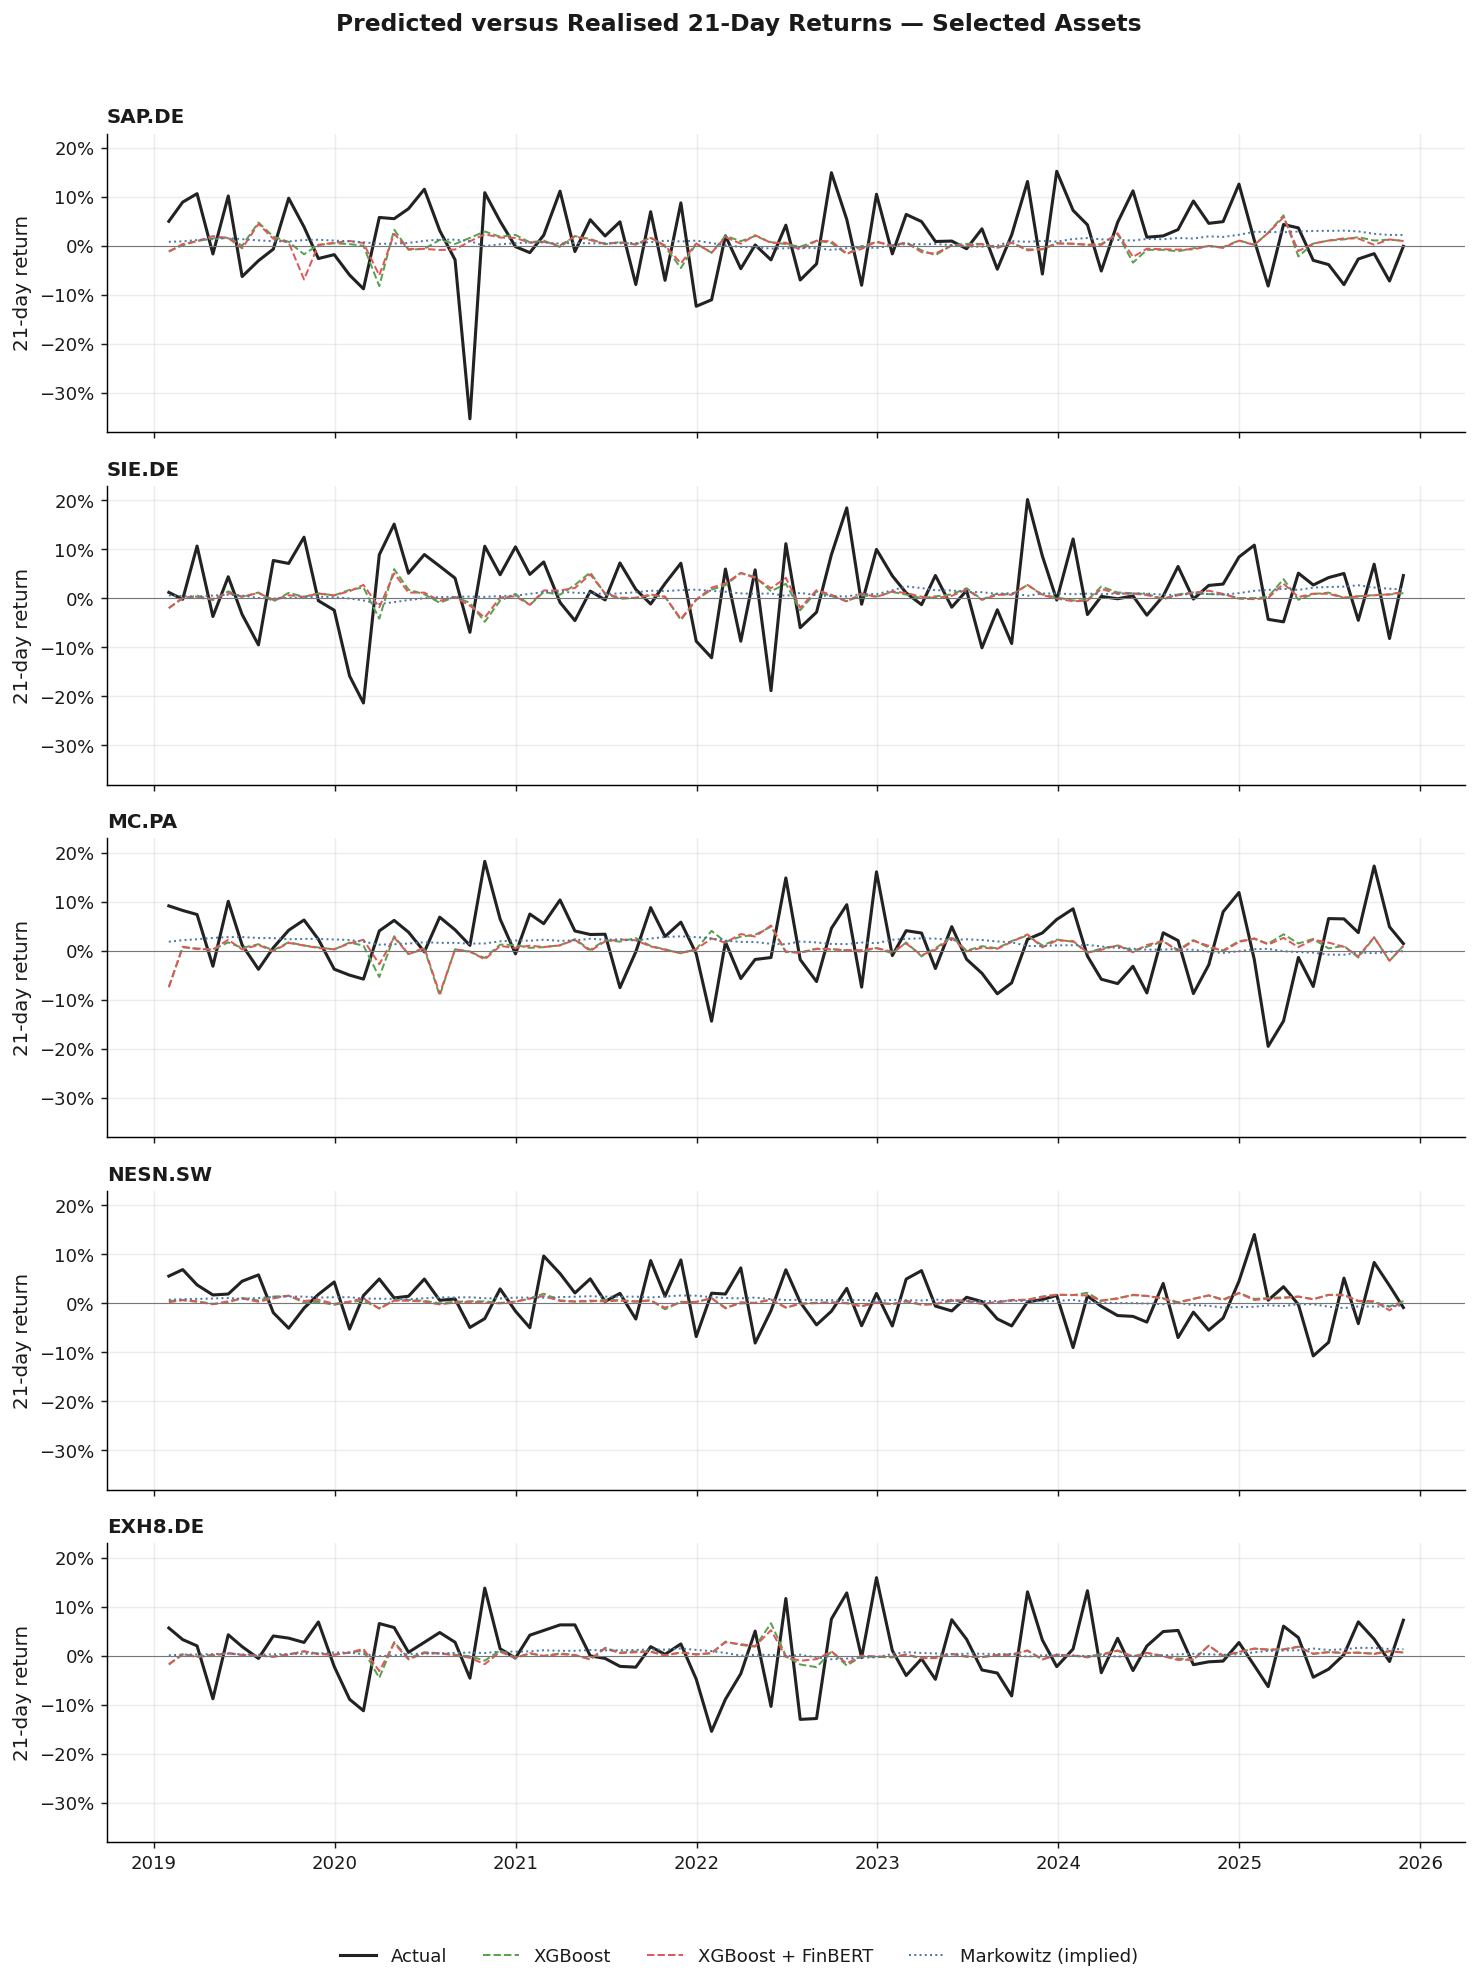

,XGBoost MAE,XGBoost + FinBERT MAE,Markowitz MAE,Sentiment effect
ticker,,,,
SAP.DE,6.24%,6.21%,5.87%,Improved
SIE.DE,6.31%,6.24%,6.09%,Improved
MC.PA,6.11%,6.06%,5.59%,Improved
NESN.SW,3.87%,3.87%,3.67%,Worsened or tied
EXH8.DE,5.02%,5.02%,4.92%,Worsened or tied


,,Actual,XGBoost,XGBoost + FinBERT,Markowitz (implied)
Period,Date,,,,
1,2019-01-31,5.01%,-1.09%,-1.20%,0.82%
2,2019-02-28,8.93%,0.12%,0.38%,0.92%
3,2019-03-29,10.65%,0.98%,0.96%,1.19%
4,2019-04-30,-1.66%,1.52%,1.99%,1.36%
5,2019-05-31,10.19%,1.72%,1.57%,1.58%
6,2019-06-28,-6.27%,0.02%,-0.51%,1.36%
7,2019-07-31,-3.04%,4.76%,4.47%,1.13%
8,2019-08-30,-0.67%,1.87%,1.45%,0.95%
9,2019-09-30,9.73%,0.80%,0.68%,0.91%


,,Actual,XGBoost,XGBoost + FinBERT,Markowitz (implied)
Period,Date,,,,
1,2019-01-31,1.20%,-2.01%,-1.99%,0.60%
2,2019-02-28,-0.20%,-0.00%,0.11%,0.46%
3,2019-03-29,10.67%,0.54%,0.11%,0.34%
4,2019-04-30,-3.72%,-0.38%,-0.13%,0.57%
5,2019-05-31,4.40%,1.43%,1.05%,0.72%
6,2019-06-28,-3.30%,0.25%,0.35%,0.56%
7,2019-07-31,-9.52%,1.20%,1.06%,0.08%
8,2019-08-30,7.72%,-0.65%,-0.35%,-0.06%
9,2019-09-30,7.12%,1.11%,0.62%,0.08%


,,Actual,XGBoost,XGBoost + FinBERT,Markowitz (implied)
Period,Date,,,,
1,2019-01-31,9.16%,-7.38%,-7.45%,1.84%
2,2019-02-28,8.23%,0.71%,0.84%,2.17%
3,2019-03-29,7.40%,0.48%,0.33%,2.35%
4,2019-04-30,-3.16%,0.21%,0.27%,2.63%
5,2019-05-31,10.10%,1.72%,2.24%,2.79%
6,2019-06-28,1.18%,0.59%,0.26%,2.81%
7,2019-07-31,-3.79%,1.33%,1.18%,2.61%
8,2019-08-30,0.62%,0.08%,-0.09%,2.58%
9,2019-09-30,4.19%,1.74%,1.60%,2.33%


,,Actual,XGBoost,XGBoost + FinBERT,Markowitz (implied)
Period,Date,,,,
1,2019-01-31,5.54%,0.44%,0.20%,0.70%
2,2019-02-28,6.87%,0.66%,0.61%,0.82%
3,2019-03-29,3.74%,0.39%,0.29%,0.88%
4,2019-04-30,1.69%,-0.14%,-0.23%,0.96%
5,2019-05-31,1.87%,0.16%,0.41%,1.06%
6,2019-06-28,4.49%,1.09%,0.96%,0.89%
7,2019-07-31,5.78%,0.55%,0.29%,1.06%
8,2019-08-30,-1.94%,1.35%,0.98%,1.29%
9,2019-09-30,-5.11%,1.52%,1.55%,1.36%


,,Actual,XGBoost,XGBoost + FinBERT,Markowitz (implied)
Period,Date,,,,
1,2019-01-31,5.65%,-1.83%,-1.72%,0.07%
2,2019-02-28,3.28%,0.34%,0.22%,0.21%
3,2019-03-29,2.00%,-0.18%,-0.23%,0.24%
4,2019-04-30,-8.81%,0.18%,-0.04%,0.31%
5,2019-05-31,4.27%,0.43%,0.57%,0.43%
6,2019-06-28,1.84%,0.16%,0.13%,0.25%
7,2019-07-31,-0.56%,0.02%,0.00%,0.21%
8,2019-08-30,4.03%,-0.17%,-0.23%,0.28%
9,2019-09-30,3.58%,0.29%,0.18%,0.35%


Detailed selected-asset table saved to: /Users/harshkataria/Desktop/Thesis/model/data/results/prediction_accuracy_selected_assets.csv


In [28]:
N_ASSETS = 5
MANUAL_TICKERS = [
    "SAP.DE",
    "SIE.DE",
    "MC.PA",
    "NESN.SW",
    "EXH8.DE",
]

required_path_columns = {"date", "ticker", "actual", "xgb_predicted",
                         "xgb_sentiment_predicted"}
if pred_acc is None or not required_path_columns.issubset(pred_acc.columns):
    print("Prediction-path columns unavailable; selected-asset paths skipped.")
else:
    N_ASSETS = max(1, min(7, int(N_ASSETS)))
    available_tickers = list(pred_acc["ticker"].dropna().drop_duplicates())
    if MANUAL_TICKERS is not None:
        missing_manual = [ticker for ticker in MANUAL_TICKERS
                          if ticker not in available_tickers]
        if missing_manual:
            warnings.warn(f"Ignoring tickers absent from prediction data: {missing_manual}")
        selected = [ticker for ticker in dict.fromkeys(MANUAL_TICKERS)
                    if ticker in available_tickers][:N_ASSETS]
    else:
        candidates = []
        if "EXSA.DE" in available_tickers:
            candidates.append("EXSA.DE")
        if per_ticker is not None:
            candidates.extend(per_ticker.nlargest(4, "mae_improvement").index)
            candidates.extend(per_ticker.nsmallest(4, "mae_improvement").index)
        candidates.extend(available_tickers)
        selected = list(dict.fromkeys(candidates))[:N_ASSETS]

    if not selected:
        raise ValueError("No selected ticker has prediction-accuracy data.")

    prediction_paths = pred_acc[pred_acc["ticker"].isin(selected)].copy()
    markowitz_frame = None
    clean_prices_path = Path(CLEAN_PRICES_FILE)
    if clean_prices_path.exists():
        prices = pd.read_csv(clean_prices_path, index_col=0, parse_dates=True).sort_index()
        usable = [ticker for ticker in selected if ticker in prices.columns]
        missing_prices = [ticker for ticker in selected if ticker not in prices.columns]
        if missing_prices:
            warnings.warn(f"Markowitz path unavailable for: {missing_prices}")
        if usable:
            daily_log_returns = np.log(prices[usable]).diff()
            markowitz_rows = []
            for date in sorted(prediction_paths["date"].dropna().unique()):
                date = pd.Timestamp(date)
                window = daily_log_returns.loc[:date].tail(756)
                if len(window) < 252:
                    continue
                implied = window.mean(skipna=True) * 21
                for ticker, value in implied.items():
                    markowitz_rows.append({
                        "date": date, "ticker": ticker, "markowitz_implied": value
                    })
            markowitz_frame = pd.DataFrame(markowitz_rows)
            if not markowitz_frame.empty:
                prediction_paths = prediction_paths.merge(
                    markowitz_frame, on=["date", "ticker"], how="left"
                )
    else:
        warnings.warn(f"{clean_prices_path} not found; Markowitz comparison omitted.")

    all_dates = sorted(prediction_paths["date"].dropna().unique())
    period_lookup = {date: number for number, date in enumerate(all_dates, start=1)}
    prediction_paths["period"] = prediction_paths["date"].map(period_lookup)

    fig, axes = plt.subplots(len(selected), 1, figsize=(11.5, 3.0 * len(selected)),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes)
    for ax, ticker in zip(axes, selected):
        subset = prediction_paths[prediction_paths["ticker"] == ticker].sort_values("date")
        ax.plot(subset["date"], subset["actual"], color="#222222", linewidth=1.7,
                label="Actual")
        ax.plot(subset["date"], subset["xgb_predicted"], color=color("xgb"),
                linewidth=1.1, linestyle="--", label="XGBoost")
        ax.plot(subset["date"], subset["xgb_sentiment_predicted"],
                color=color("xgb_sentiment"), linewidth=1.1, linestyle="--",
                label="XGBoost + FinBERT")
        if "markowitz_implied" in subset.columns:
            ax.plot(subset["date"], subset["markowitz_implied"],
                    color=color("markowitz"), linewidth=1.1, linestyle=":",
                    label="Markowitz (implied)")
        ax.axhline(0, color="#777777", linewidth=0.6)
        ax.set_title(ticker, loc="left", fontsize=11)
        ax.set_ylabel("21-day return")
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[-1].xaxis.set_major_locator(mdates.YearLocator())
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    handles, legend_labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, legend_labels, loc="lower center", ncol=len(handles),
               bbox_to_anchor=(0.5, -0.01))
    fig.suptitle("Predicted versus Realised 21-Day Returns — Selected Assets", y=1.0,
                 fontsize=13, weight="bold")
    fig.tight_layout(rect=(0, 0.035, 1, 0.985))
    if EXPORT_FIGURES:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGURES_DIR / "appendixB_predicted_vs_actual_paths.png",
                    dpi=300, bbox_inches="tight")
    plt.show()

    prediction_paths["xgb_error"] = (
        prediction_paths["xgb_predicted"] - prediction_paths["actual"]
    ).abs()
    prediction_paths["xgb_sentiment_error"] = (
        prediction_paths["xgb_sentiment_predicted"] - prediction_paths["actual"]
    ).abs()
    error_columns = ["xgb_error", "xgb_sentiment_error"]
    summary_names = ["XGBoost MAE", "XGBoost + FinBERT MAE"]
    if "markowitz_implied" in prediction_paths.columns:
        prediction_paths["markowitz_error"] = (
            prediction_paths["markowitz_implied"] - prediction_paths["actual"]
        ).abs()
        error_columns.append("markowitz_error")
        summary_names.append("Markowitz MAE")
    selected_summary = prediction_paths.groupby("ticker")[error_columns].mean()
    selected_summary.columns = summary_names
    selected_summary = selected_summary.reindex(selected)
    selected_summary["Sentiment effect"] = np.where(
        selected_summary["XGBoost + FinBERT MAE"] < selected_summary["XGBoost MAE"],
        "Improved", "Worsened or tied"
    )
    styled_summary = (selected_summary.style
                      .format({column: "{:.2%}" for column in summary_names}, na_rep="—")
                      .highlight_min(subset=summary_names, axis=1, props=HIGHLIGHT_PROPS))
    styled_summary = styled_summary.map(
        lambda value: (HIGHLIGHT_PROPS if value == "Improved"
                      else f"background-color:{NEG_COLOR};color:white;font-weight:600"),
        subset=["Sentiment effect"],
    )
    display(styled_summary.set_caption(
        "Selected-asset mean absolute error across all periods — dark green marks the "
        "lower-error model per row, and rows where sentiment improved accuracy"))

    detail_columns = ["period", "date", "ticker", "actual", "xgb_predicted",
                      "xgb_sentiment_predicted"]
    if "markowitz_implied" in prediction_paths.columns:
        detail_columns.append("markowitz_implied")
    detail = prediction_paths[detail_columns].copy().sort_values(["ticker", "date"])
    detail = detail.rename(columns={
        "period": "Period", "date": "Date", "ticker": "Ticker",
        "actual": "Actual", "xgb_predicted": "XGBoost",
        "xgb_sentiment_predicted": "XGBoost + FinBERT",
        "markowitz_implied": "Markowitz (implied)",
    })
    detail["Date"] = pd.to_datetime(detail["Date"]).dt.date
    return_columns = [column for column in [
        "Actual", "XGBoost", "XGBoost + FinBERT", "Markowitz (implied)"
    ] if column in detail.columns]
    for ticker in selected:
        ticker_table = detail[detail["Ticker"] == ticker].drop(columns="Ticker")
        display(ticker_table.set_index(["Period", "Date"]).style
                .format({column: "{:.2%}" for column in return_columns}, na_rep="—")
                .set_caption(f"{ticker}: every out-of-sample prediction period"))

    export_path = RESULTS_DIR / "prediction_accuracy_selected_assets.csv"
    detail.to_csv(export_path, index=False)
    print(f"Detailed selected-asset table saved to: {export_path}")


<a id="secC"></a>
## Appendix C. January 2026 forecast versus actual outcome (optional)

This section preserves the added forecast/actual price and return comparison
without retraining models or downloading live prices. It reads the saved output
created by Appendix D below (or an earlier run of it), presents the full table,
and recreates the return and price charts. This is a post-sample case study,
not part of the 2019–2025 backtest.

Type,Asset,Ticker,Information date,Actual end date,Actual sessions,Starting price,XGBoost predicted price,Sentiment predicted price,Markowitz predicted price,Actual price,XGBoost return,Sentiment return,Markowitz return,Actual return,Sentiment adjustment
ETF,iShares STOXX Europe 600 Retail UCITS ETF,EXH8.DE,31 Dec 2025,30 Jan 2026,21,€45.53,€45.87,€45.86,€46.03,€45.69,+0.75%,+0.72%,+1.09%,+0.34%,-0.02%
Stock,SAP SE,SAP.DE,31 Dec 2025,30 Jan 2026,21,€204.87,€209.20,€209.00,€209.03,€167.71,+2.11%,+2.02%,+2.03%,-18.14%,-0.10%
Stock,Siemens AG,SIE.DE,31 Dec 2025,30 Jan 2026,21,€234.17,€234.66,€234.76,€238.02,€250.96,+0.21%,+0.25%,+1.64%,+7.17%,+0.04%
Stock,LVMH,MC.PA,31 Dec 2025,30 Jan 2026,21,€634.65,€641.30,€640.02,€631.85,€538.13,+1.05%,+0.85%,-0.44%,-15.21%,-0.20%
Stock,Nestlé SA,NESN.SW,31 Dec 2025,02 Feb 2026,21,€81.44,€82.24,€82.16,€81.07,€72.55,+0.98%,+0.88%,-0.45%,-10.92%,-0.10%


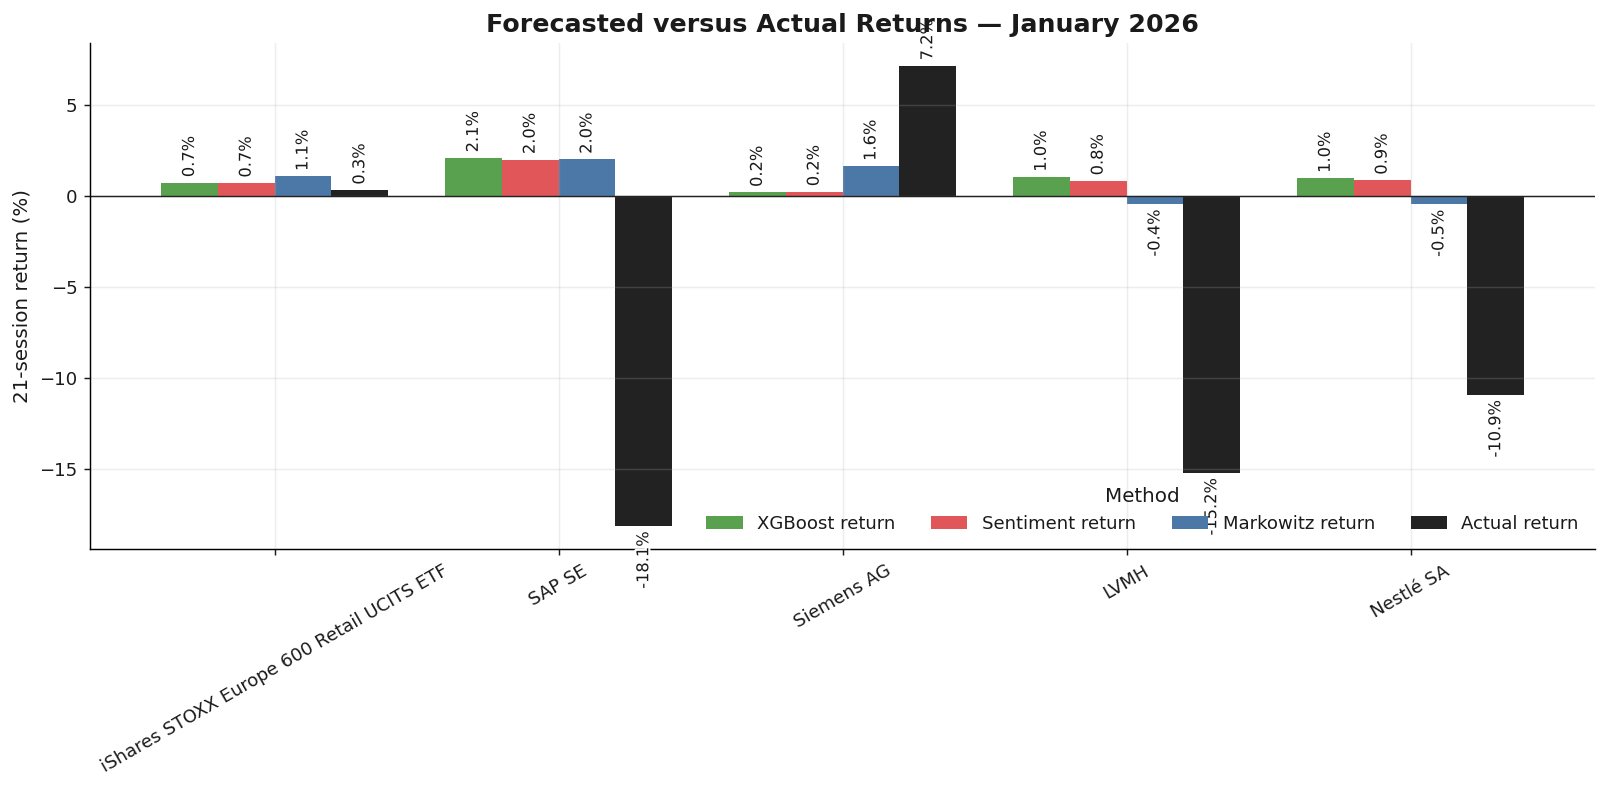

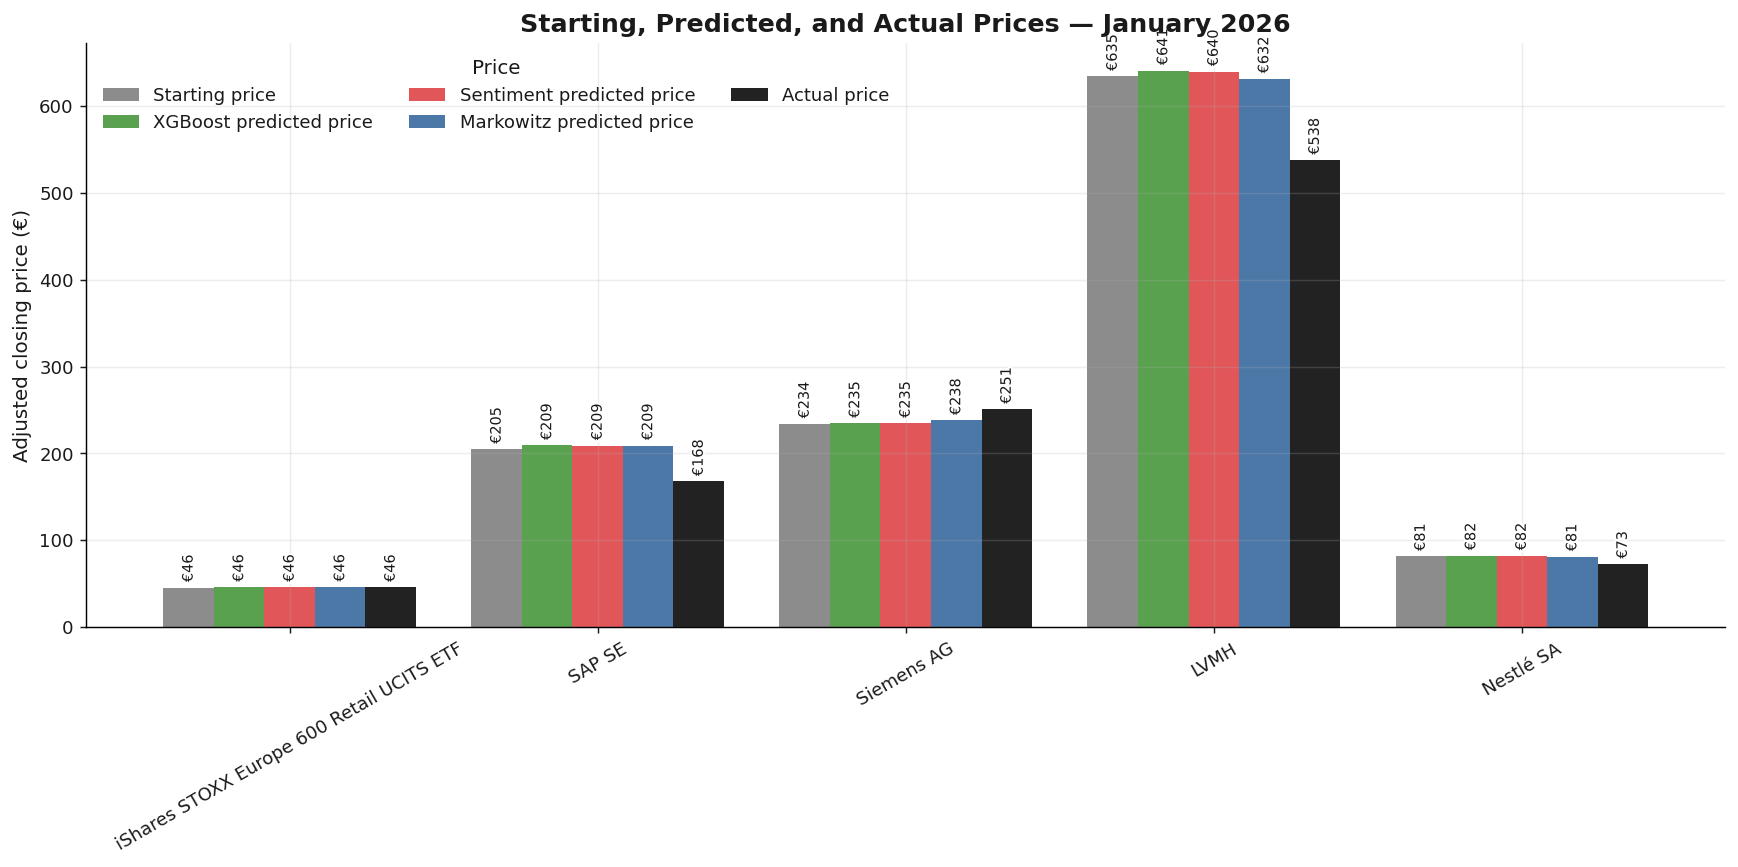

In [29]:
january_candidates = [
    RESULTS_DIR / "january_2026_forecast_prices_vs_actual.csv",
    RESULTS_DIR / "january_2026_prices_returns.csv",
    RESULTS_DIR / "january_2026_forecast_vs_actual.csv",
]
january_path = next((path for path in january_candidates if path.exists()), None)

if january_path is None:
    print("No January 2026 forecast-versus-actual CSV found; optional section skipped. "
          "Run Appendix D to generate it.")
else:
    january = pd.read_csv(january_path)

    def normalized_column_name(name):
        return "".join(character.lower() for character in str(name) if character.isalnum())

    column_lookup = {normalized_column_name(column): column for column in january.columns}
    aliases = {
        "Asset": ["asset", "assetname", "name"],
        "Ticker": ["ticker", "symbol"],
        "Starting price": ["startingprice", "startprice", "initialprice", "informationprice"],
        "XGBoost predicted price": ["xgboostpredictedprice", "xgbpredictedprice",
                                     "model3predictedprice"],
        "Sentiment predicted price": ["sentimentpredictedprice",
                                      "xgboostsentimentpredictedprice",
                                      "xgbsentimentpredictedprice",
                                      "model4predictedprice"],
        "Markowitz predicted price": ["markowitzpredictedprice", "mvopredictedprice",
                                       "model1predictedprice"],
        "Actual price": ["actualprice", "realisedprice", "realizedprice"],
        "XGBoost return": ["xgboostreturn", "xgbreturn", "xgbforecastreturn",
                            "xgbpredictedreturn", "model3return", "model3forecast"],
        "Sentiment return": ["sentimentreturn", "xgboostsentimentreturn",
                             "xgbsentimentreturn", "xgbsentimentpredictedreturn",
                             "model4return", "model4forecast"],
        "Markowitz return": ["markowitzreturn", "mvoreturn", "model1return",
                              "model1forecast"],
        "Actual return": ["actualreturn", "realisedreturn", "realizedreturn"],
        "Sentiment adjustment": ["sentimentadjustment"],
    }
    rename_columns = {}
    for canonical, candidates in aliases.items():
        for candidate in candidates:
            if candidate in column_lookup:
                rename_columns[column_lookup[candidate]] = canonical
                break
    january = january.rename(columns=rename_columns)

    identifier = "Asset" if "Asset" in january.columns else (
        "Ticker" if "Ticker" in january.columns else january.columns[0]
    )
    price_columns = [column for column in [
        "Starting price", "XGBoost predicted price", "Sentiment predicted price",
        "Markowitz predicted price", "Actual price"
    ] if column in january.columns]
    return_columns = [column for column in [
        "XGBoost return", "Sentiment return", "Markowitz return", "Actual return",
        "Sentiment adjustment"
    ] if column in january.columns]

    formats = {column: "€{:,.2f}" for column in price_columns}
    formats.update({column: "{:+.2%}" for column in return_columns})
    styled_january = january.style.hide(axis="index").format(formats, na_rep="—")
    if "Sentiment adjustment" in january.columns:
        styled_january = sign_style(styled_january, subset=["Sentiment adjustment"],
                                     neutral_band=0.0005)
    display(styled_january.set_caption(
        f"January 2026 forecast versus actual outcome ({january_path.name}) — dark "
        "green: sentiment pushed the forecast up, red: pushed down, amber: negligible"))

    if return_columns:
        chart_returns = [column for column in [
            "XGBoost return", "Sentiment return", "Markowitz return", "Actual return"
        ] if column in january.columns]
        return_chart = january.set_index(identifier)[chart_returns] * 100
        return_colors = {
            "XGBoost return": color("xgb"),
            "Sentiment return": color("xgb_sentiment"),
            "Markowitz return": color("markowitz"),
            "Actual return": "#222222",
        }
        ax = return_chart.plot(kind="bar", figsize=(12.5, 6.2), width=0.8,
                               color=[return_colors[column] for column in chart_returns])
        ax.axhline(0, color="#222222", linewidth=0.8)
        ax.set_title("Forecasted versus Actual Returns — January 2026")
        ax.set_xlabel("")
        ax.set_ylabel("21-session return (%)")
        ax.legend(title="Method", ncol=min(4, len(chart_returns)))
        ax.tick_params(axis="x", rotation=30)
        annotate_bars(ax, value_fmt=lambda v: f"{v:.1f}%", fontsize=9, rotation=90)
        plt.tight_layout()
        if EXPORT_FIGURES:
            FIGURES_DIR.mkdir(parents=True, exist_ok=True)
            plt.savefig(FIGURES_DIR / "appendixC_january_returns.png",
                        dpi=300, bbox_inches="tight")
        plt.show()

    if price_columns:
        chart_prices = [column for column in [
            "Starting price", "XGBoost predicted price", "Sentiment predicted price",
            "Markowitz predicted price", "Actual price"
        ] if column in january.columns]
        price_chart = january.set_index(identifier)[chart_prices]
        price_colors = {
            "Starting price": "#8C8C8C",
            "XGBoost predicted price": color("xgb"),
            "Sentiment predicted price": color("xgb_sentiment"),
            "Markowitz predicted price": color("markowitz"),
            "Actual price": "#222222",
        }
        ax = price_chart.plot(kind="bar", figsize=(13.5, 6.8), width=0.82,
                              color=[price_colors[column] for column in chart_prices])
        ax.set_title("Starting, Predicted, and Actual Prices — January 2026")
        ax.set_xlabel("")
        ax.set_ylabel("Adjusted closing price (€)")
        ax.legend(title="Price", ncol=min(3, len(chart_prices)))
        ax.tick_params(axis="x", rotation=30)
        annotate_bars(ax, value_fmt=lambda v: f"€{v:,.0f}", fontsize=8, rotation=90)
        plt.tight_layout()
        if EXPORT_FIGURES:
            plt.savefig(FIGURES_DIR / "appendixC_january_prices.png",
                        dpi=300, bbox_inches="tight")
        plt.show()

    if not price_columns and not return_columns:
        print("The saved CSV was displayed, but its columns did not match known chart fields.")


In [30]:
%pip install nbconvert


Note: you may need to restart the kernel to use updated packages.
